In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

# import libraries:
import sys, os
os.environ['TF_USE_LEGACY_KERAS'] = '1'  # needed for tensorflow KERAS compatibility
os.environ['DISPLAY'] = 'inline'  # hack to get getdist working
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../tensiometer')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# tensorflow imports:
import tensorflow as tf
import tensorflow_probability as tfp

print(sys.path)

# import the tensiometer tools that we need:
import tensiometer
#from tensiometer.utilities import stats_utilities as utilities # error
from tensiometer import utilities
from tensiometer.synthetic_probability import synthetic_probability as sp

# getdist settings to ensure consistency of plots:
getdist_settings = {'ignore_rows': 0.4, 
                    'smooth_scale_2D': 0.3,
                    'smooth_scale_1D': 0.3,
                    }    

2025-06-22 10:51:58.393881: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-22 10:51:58.532792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-22 10:51:58.572654: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-22 10:51:58.584143: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-22 10:51:58.613017: I tensorflow/core/platform/cpu_feature_guar

['/auto_farm/farm_fs/mraveri/projects/marialuisa/tensiometer', '/home/mraveri/software/anaconda3/envs/mlg/lib/python39.zip', '/home/mraveri/software/anaconda3/envs/mlg/lib/python3.9', '/home/mraveri/software/anaconda3/envs/mlg/lib/python3.9/lib-dynload', '', '/home/mraveri/.local/lib/python3.9/site-packages', '/home/mraveri/.local/lib/python3.9/site-packages/tensorflow_probability-0.24.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/gast-0.4.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/pymanopt-0.2.5-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/sphinx_rtd_theme-3.0.1-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/joblib-1.4.2-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/dm_tree-0.1.8-py3.9-linux-x86_64.egg', '/home/mraveri/.local/lib/python3.9/site-packages/cloudpickle-3.1.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/absl_py-2.1.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-p

In [2]:
# ADD MY CHAINS:
# Loading samples
#PLANCK_ALL
#lcdm:
chain_lcdm = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/lcdm/planck_all', '1_lcdm_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/w0wacdm/all_planck/first_attempt', '1_w0wa_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/first_attempt', '1_EXP_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)

'''
#ACT_ALL
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_all', '1_lcdm_act_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_all', '1_w0wa_act_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_all', '1_EXP_act_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)
'''

['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']
['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8'

"\n#ACT_ALL\n#lcdm:\nchain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_all', '1_lcdm_act_planck_desidr2_des')\nsamples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)\n#print('Parameters: ', samples.paramNames.names)\nparam_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]\nprint(param_names_lcdm)\n\n#w0wacdm:\nchain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_all', '1_w0wa_act_planck_desidr2_des')\nsamples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)\n#print('Parameters: ', samples.paramNames.names)\nparam_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]\nprint(param_names_w0wa)\n\n#EFT_exp:\nchain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_all', '1_EXP_act_planck_desidr2_des')\nsamples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)

In [3]:
'''
kwargs = {
          'feedback': 2,
          'plot_every': 1000,
          'pop_size': 1,
          #'cache_dir': 'test',  # set this to a directory to cache the results
          #'root_name': 'test',  # sets the name of the flow for the cache files
        }

flow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain
                          **kwargs)

flow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain
                          **kwargs)

flow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain
                          **kwargs)
'''

"\nkwargs = {\n          'feedback': 2,\n          'plot_every': 1000,\n          'pop_size': 1,\n          #'cache_dir': 'test',  # set this to a directory to cache the results\n          #'root_name': 'test',  # sets the name of the flow for the cache files\n        }\n\nflow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain\n                          **kwargs)\n\nflow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain\n                          **kwargs)\n\nflow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain\n                          **kwargs)\n"

In [4]:
'''
# we can plot training summaries to make sure training went smoothly:
flow_lcdm.training_plot()

flow_w0wa.training_plot()

flow_exp.training_plot()
'''

'\n# we can plot training summaries to make sure training went smoothly:\nflow_lcdm.training_plot()\n\nflow_w0wa.training_plot()\n\nflow_exp.training_plot()\n'

In [5]:
'''
# and we can print the training summary:
flow_lcdm.print_training_summary()

flow_w0wa.print_training_summary()

flow_exp.print_training_summary()
'''

'\n# and we can print the training summary:\nflow_lcdm.print_training_summary()\n\nflow_w0wa.print_training_summary()\n\nflow_exp.print_training_summary()\n'

In [6]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], 
                params=flow_lcdm.param_names,
                filled=True)

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], \n                params=flow_lcdm.param_names,\n                filled=True)\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], \n                params=flow_exp.param_names,\n                filled=True)\n'

Re-do:

In [7]:
'''
# this looks nice but not perfect, let's train for longer:
flow_lcdm.feedback = 1
flow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_w0wa.feedback = 1
flow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_exp.feedback = 1
flow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar
'''

"\n# this looks nice but not perfect, let's train for longer:\nflow_lcdm.feedback = 1\nflow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_w0wa.feedback = 1\nflow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_exp.feedback = 1\nflow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n"

In [8]:
# we can plot training summaries to make sure training went smoothly:
#flow_lcdm.training_plot()

In [9]:
#flow_w0wa.training_plot()

In [10]:
#flow_exp.training_plot()

In [ ]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, 
                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_lcdm.param_names,
                filled=True)
                

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, 
                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, 
                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, \n                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_lcdm.param_names,\n                filled=True)\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, \n                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, \n                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_exp.param_names,\n                filled=True)\n'

This is now much better

In [12]:
'''
ev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')
'''

"\nev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)\nprint(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')\n\nev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)\nprint(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')\n\nev_exp, eer_exp = flow_exp.evidence(weighted=True)\nprint(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')\n"

# FARLO CON AVERAGE 

In [13]:
kwargs = {
          'feedback': 1,
          'verbose': -1,
          'plot_every': 1000,
          'pop_size': 1,
          'num_flows': 5,
          'epochs': 400,
          'loss_mode': 'softadapt'
        }

average_flow_lcdm = sp.average_flow_from_chain(samples_lcdm,  # parameter difference chain
                                          **kwargs)

Training flow 0


2025-06-22 10:52:58.546237: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43598 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:31:00.0, compute capability: 8.6
2025-06-22 10:52:58.549795: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43598 MB memory:  -> device: 1, name: NVIDIA A40, pci bus id: 0000:4b:00.0, compute capability: 8.6
2025-06-22 10:52:58.553252: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43598 MB memory:  -> device: 2, name: NVIDIA A40, pci bus id: 0000:b1:00.0, compute capability: 8.6
2025-06-22 10:52:58.556455: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43598 MB memory:  -> device: 3, name: NVIDIA A40, pci bus id: 0000:ca:00.0, compute capability: 8.6


0epoch [00:00, ?epoch/s]

I0000 00:00:1750582436.188603 2887501 service.cc:146] XLA service 0x7f172033de10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750582436.188717 2887501 service.cc:154]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750582436.188727 2887501 service.cc:154]   StreamExecutor device (1): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750582436.188732 2887501 service.cc:154]   StreamExecutor device (2): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750582436.188740 2887501 service.cc:154]   StreamExecutor device (3): NVIDIA A40, Compute Capability 8.6
2025-06-22 10:53:56.225713: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-22 10:53:56.346900: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
I0000 00:00:1750582436.573714 2887501 device_compiler.h:1

Training flow 1


...

0epoch [00:00, ?epoch/s]

Training flow 3


0epoch [00:00, ?epoch/s]

Training flow 4


0epoch [00:00, ?epoch/s]

In [14]:
average_flow_w0wa = sp.average_flow_from_chain(samples_w0wa,  # parameter difference chain
                                          **kwargs)

Training flow 0


0epoch [00:00, ?epoch/s]

Training flow 1


0epoch [00:00, ?epoch/s]

Training flow 2


0epoch [00:00, ?epoch/s]

Training flow 3


0epoch [00:00, ?epoch/s]

Training flow 4


0epoch [00:00, ?epoch/s]

In [15]:
average_flow_exp = sp.average_flow_from_chain(samples_exp,  # parameter difference chain
                                          **kwargs)

Training flow 0


0epoch [00:00, ?epoch/s]

Training flow 1


0epoch [00:00, ?epoch/s]

Training flow 2


0epoch [00:00, ?epoch/s]

Training flow 3


0epoch [00:00, ?epoch/s]

Training flow 4


0epoch [00:00, ?epoch/s]

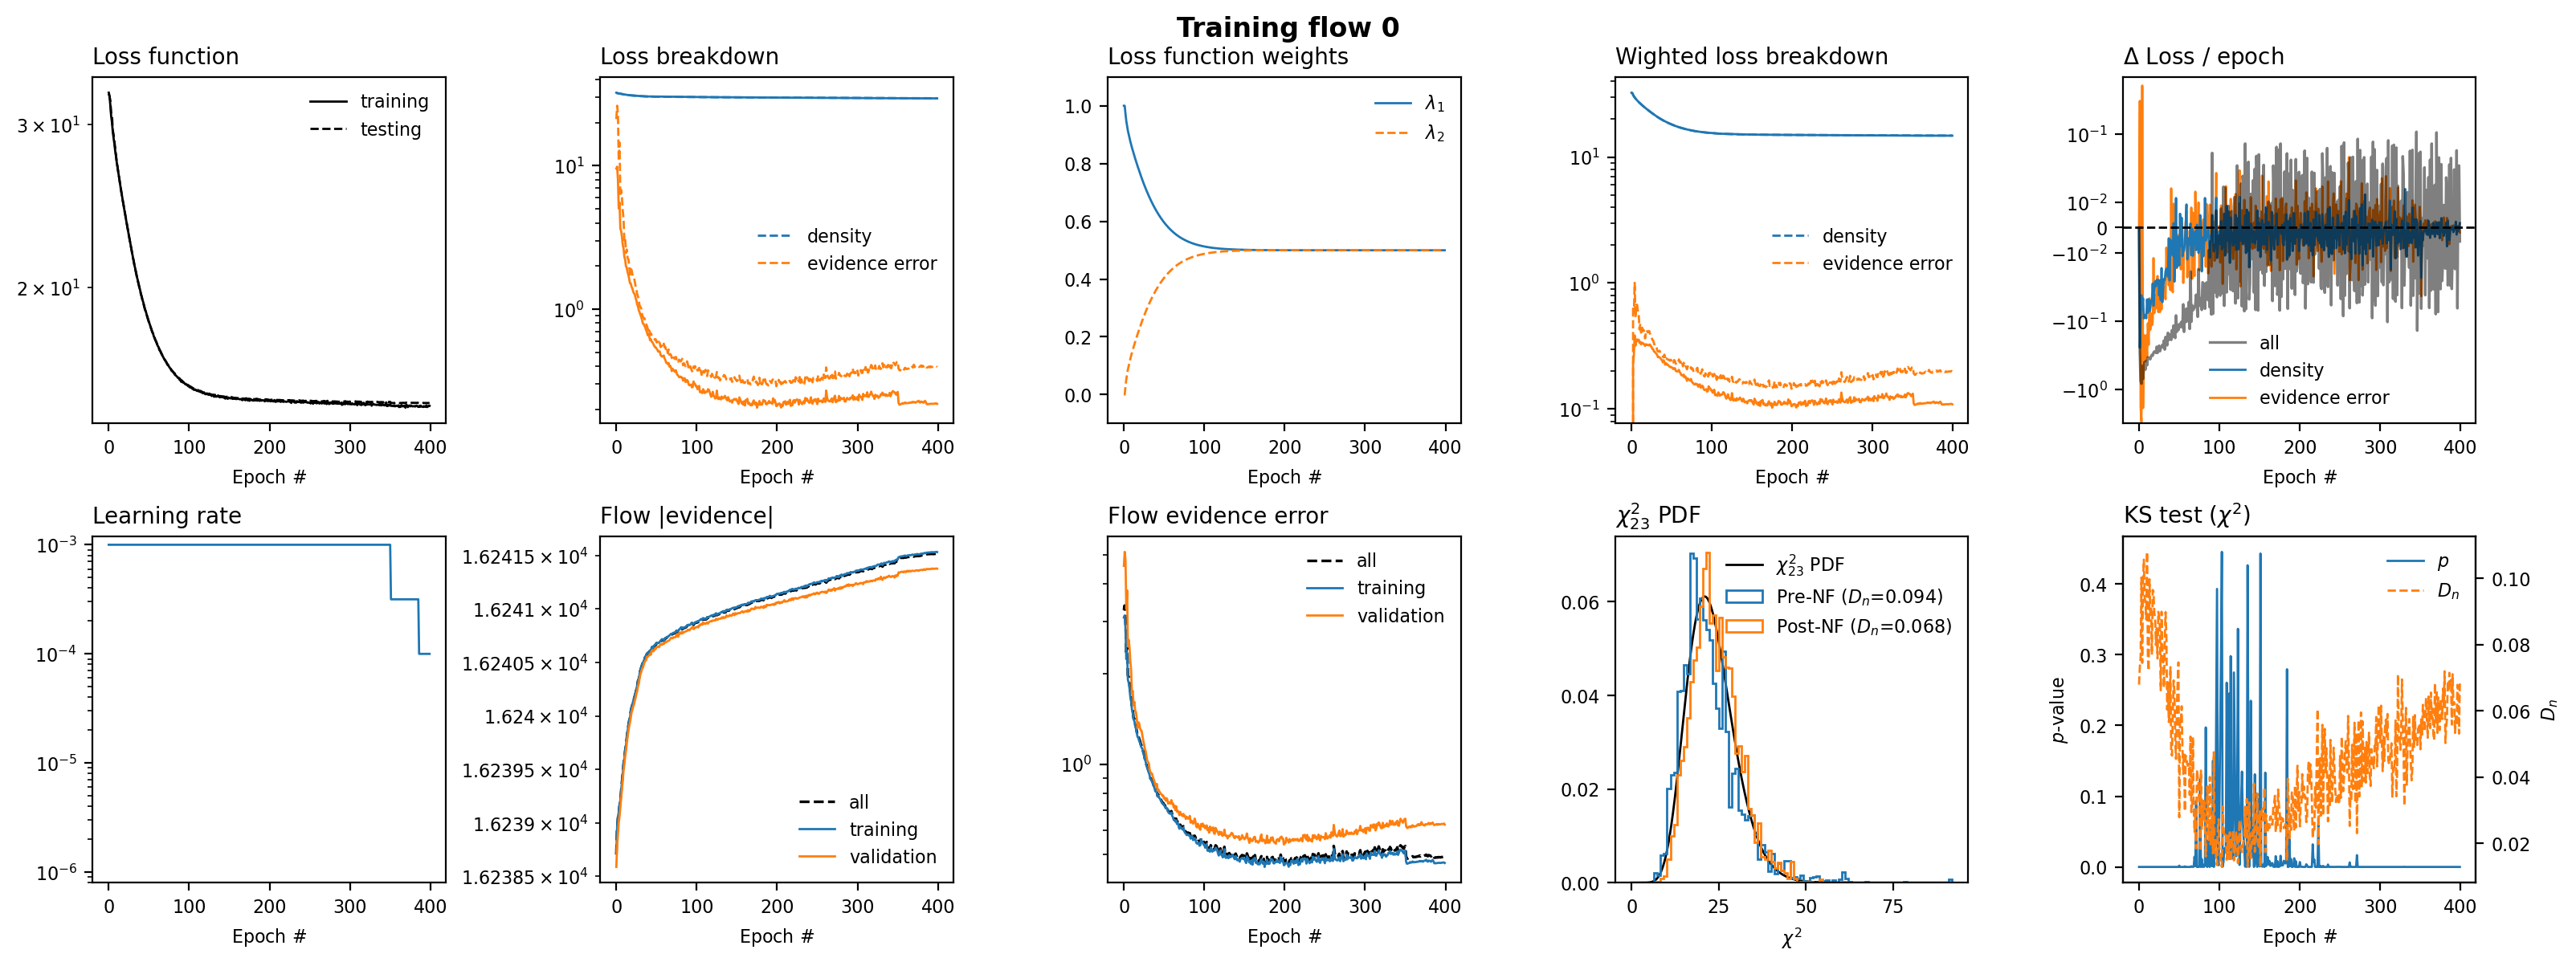

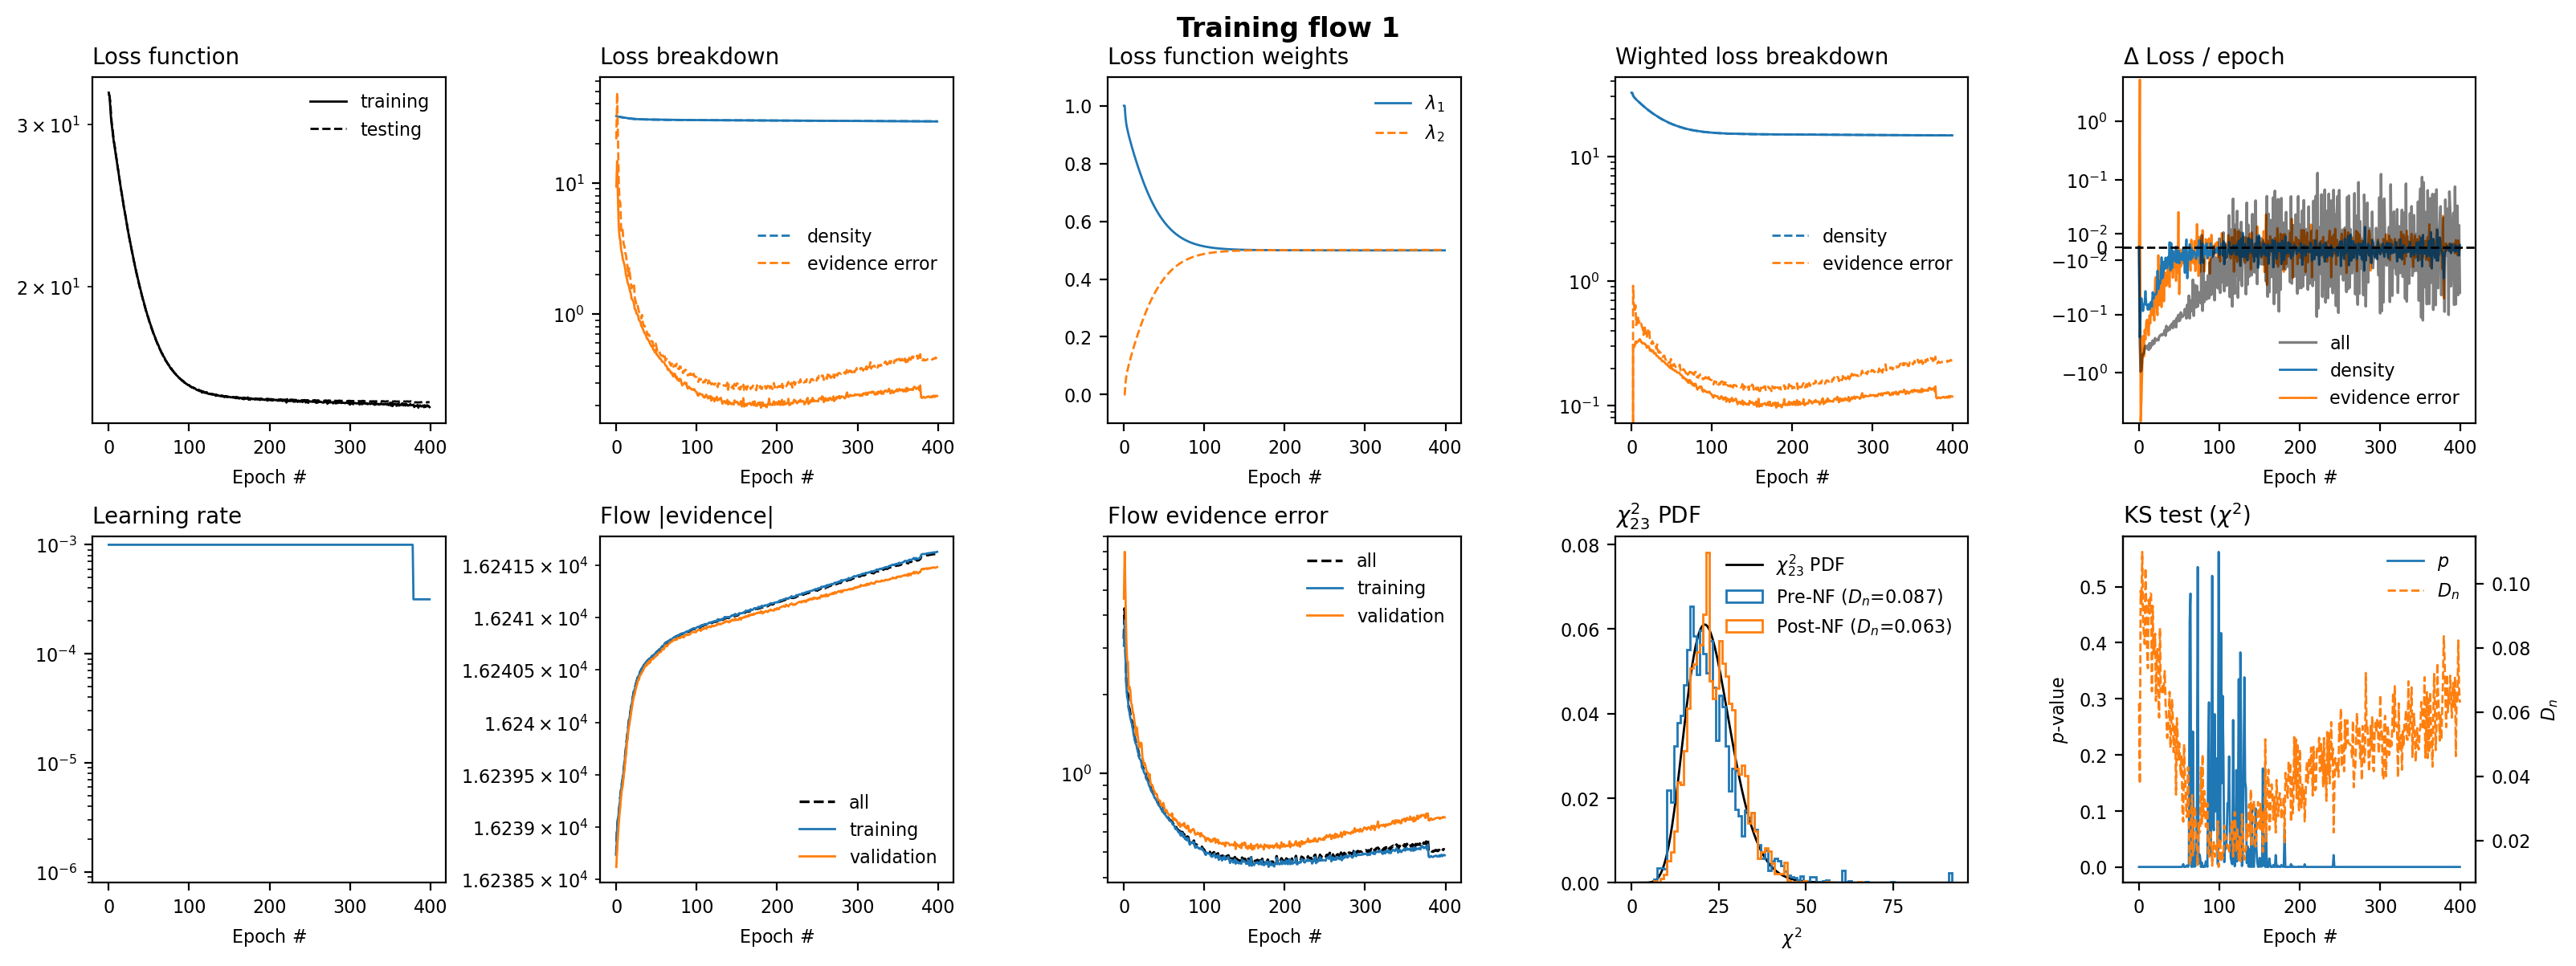

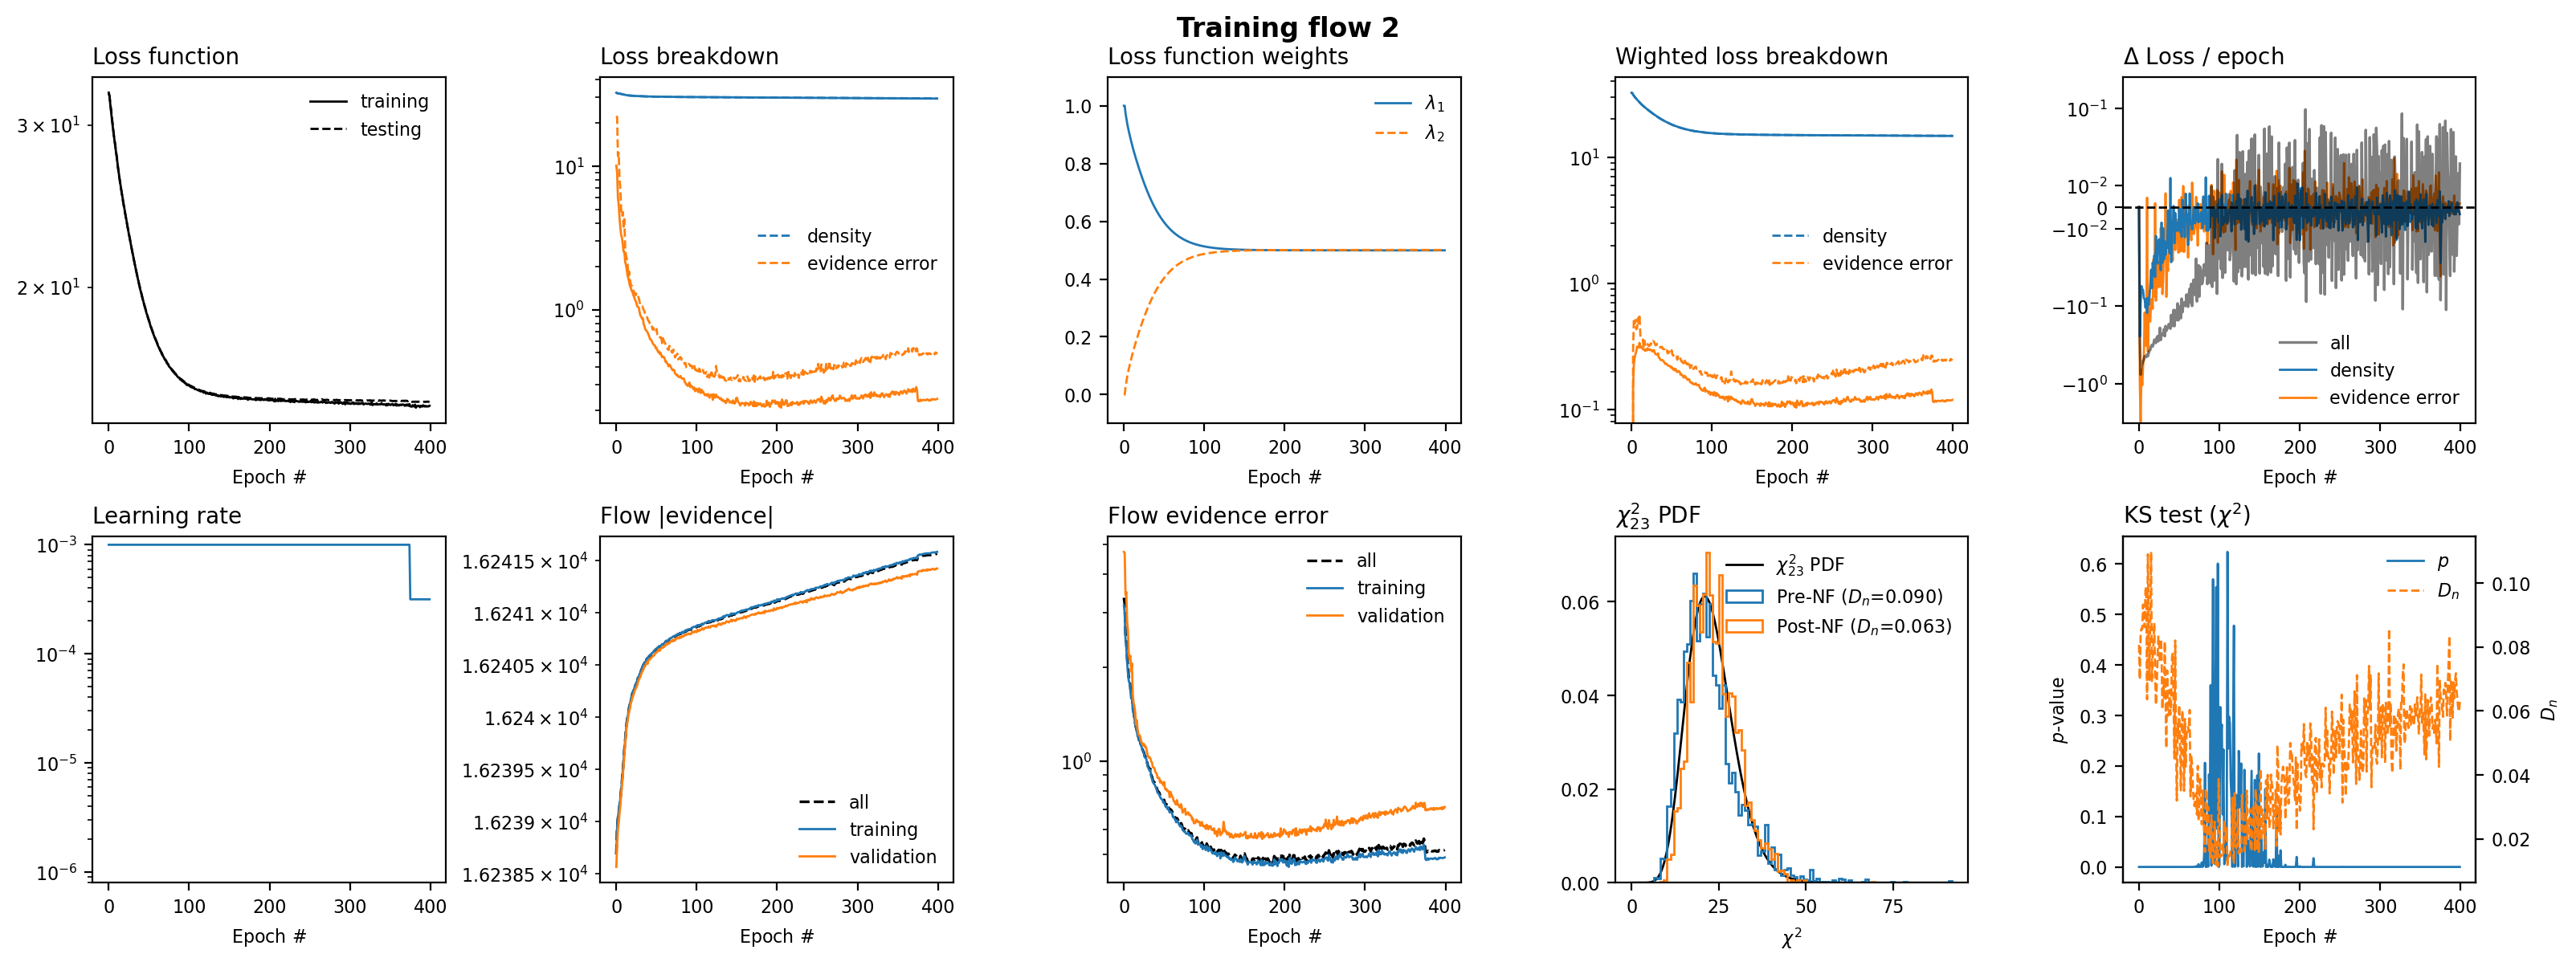

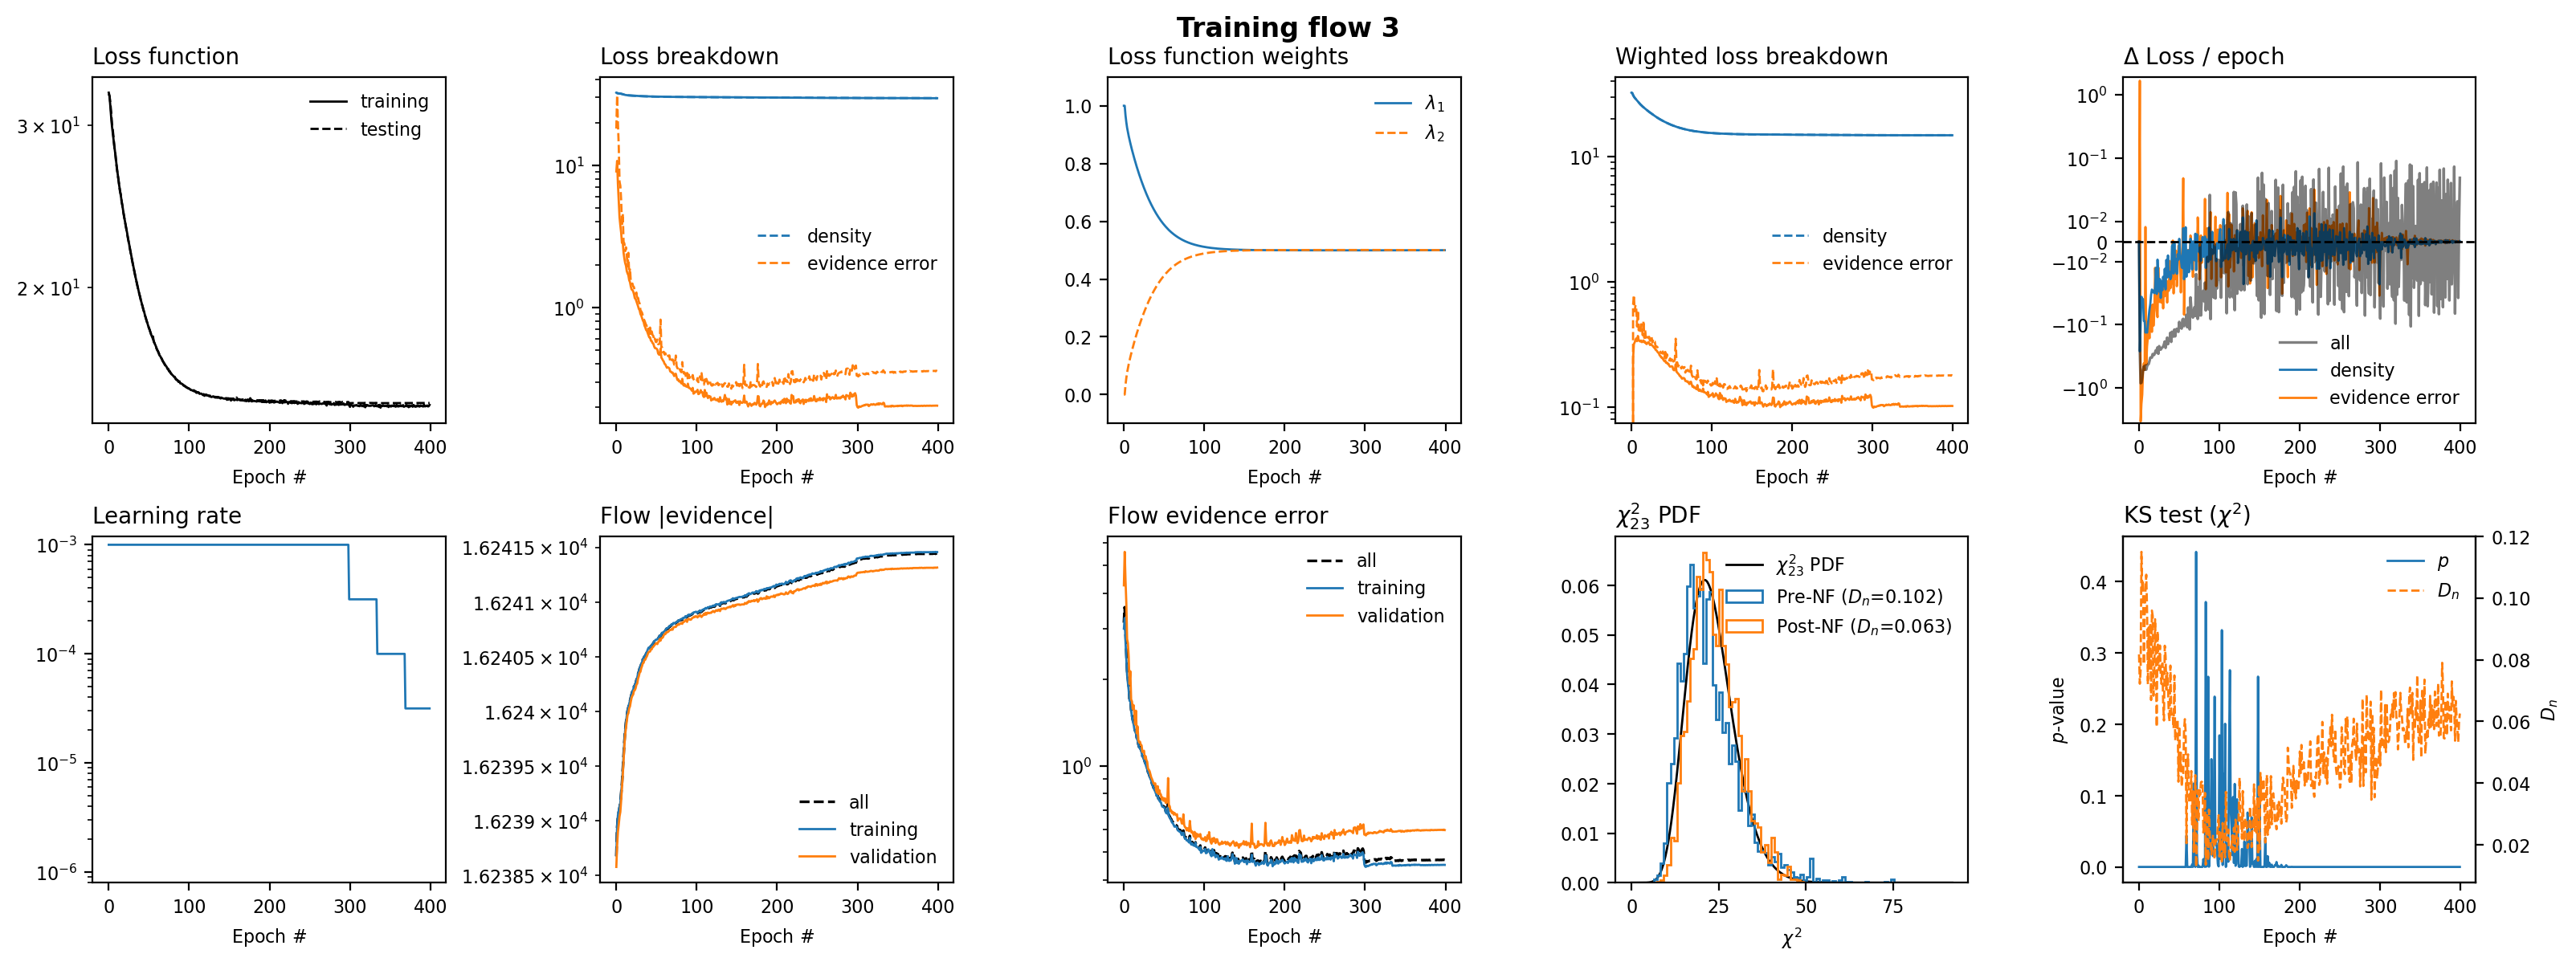

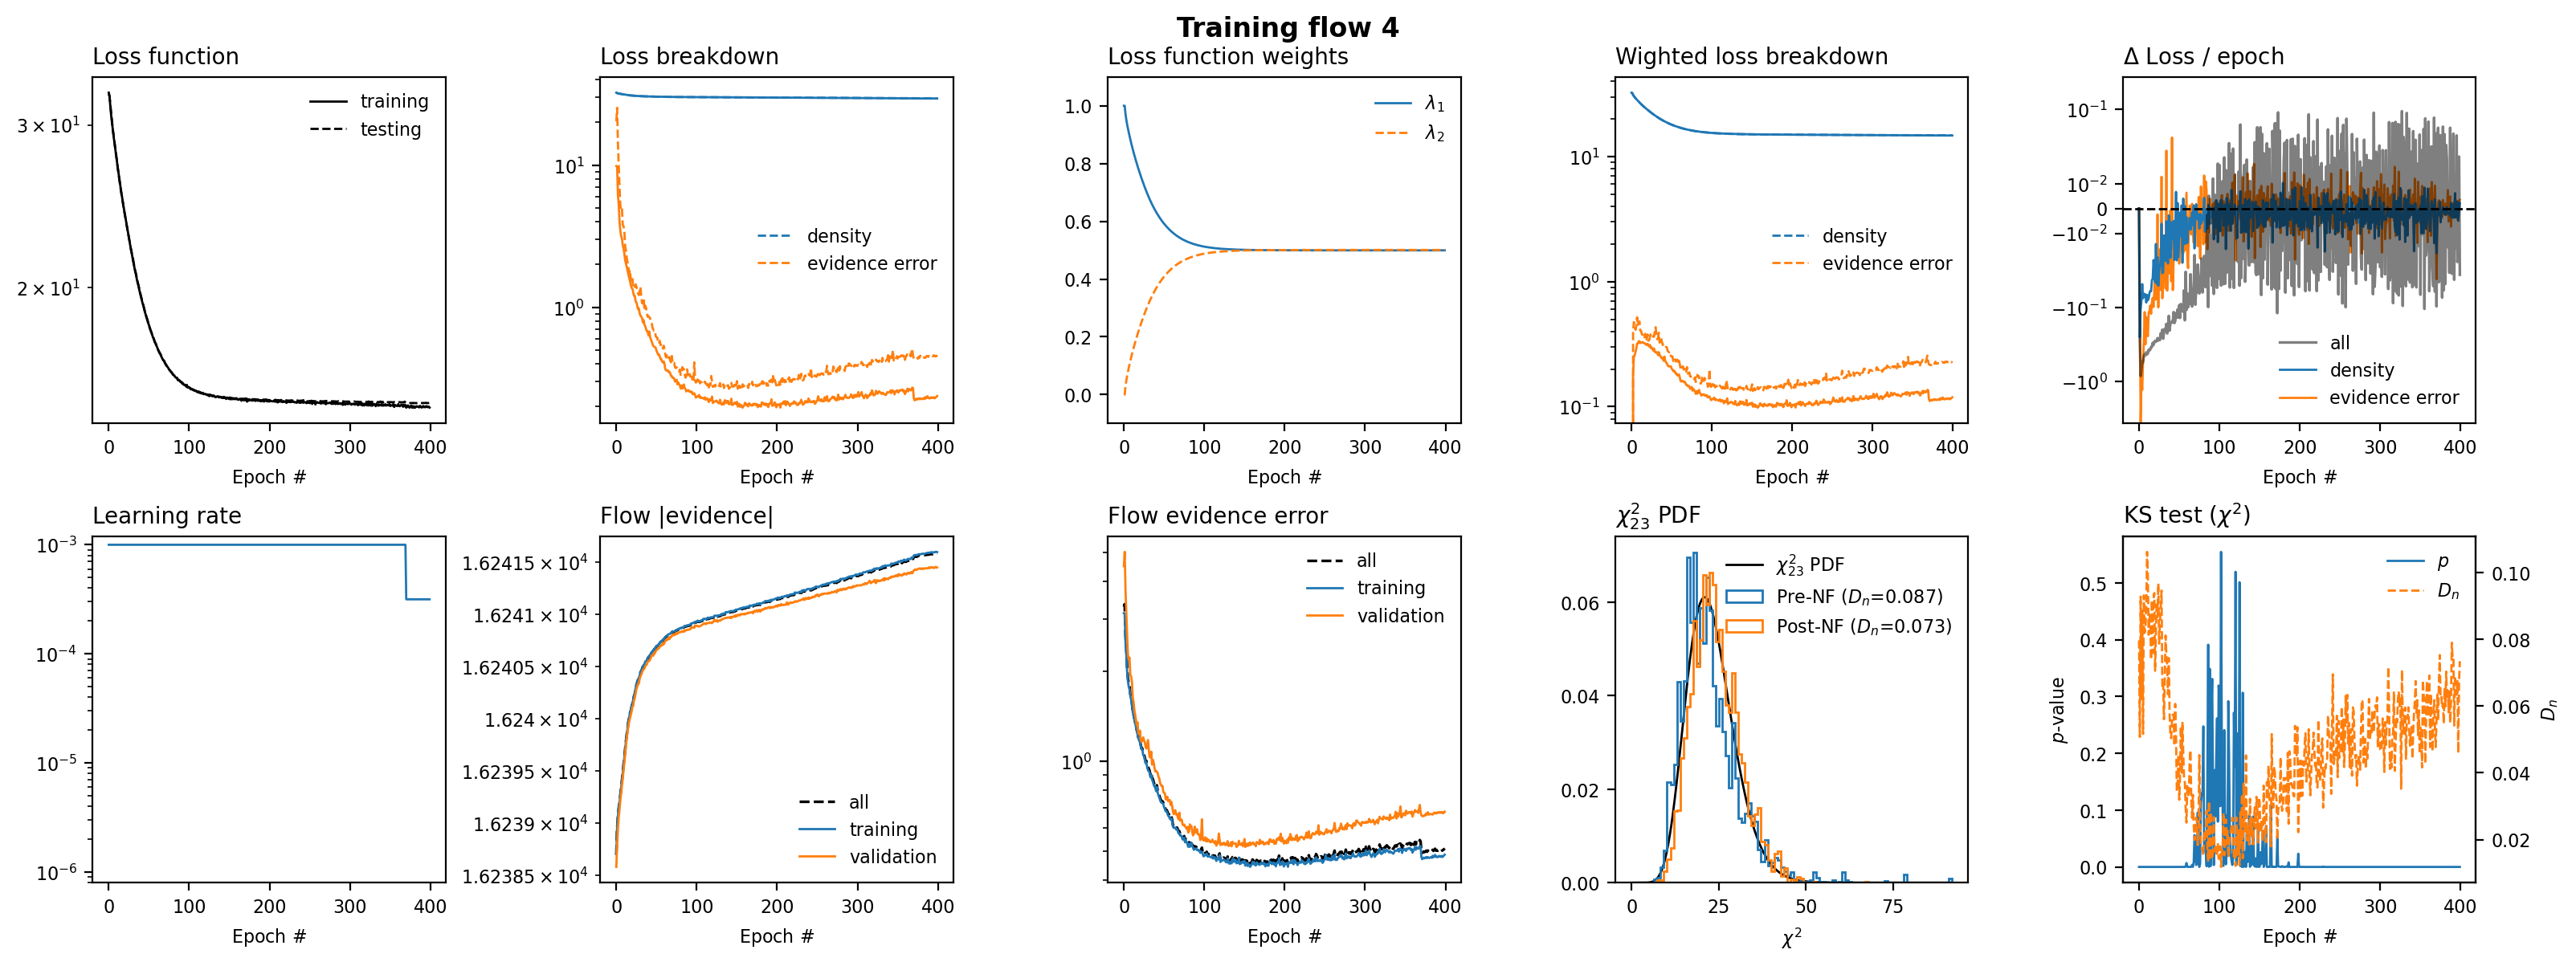

In [16]:
# most methods are implemented for the average flow as well:
average_flow_lcdm.training_plot()

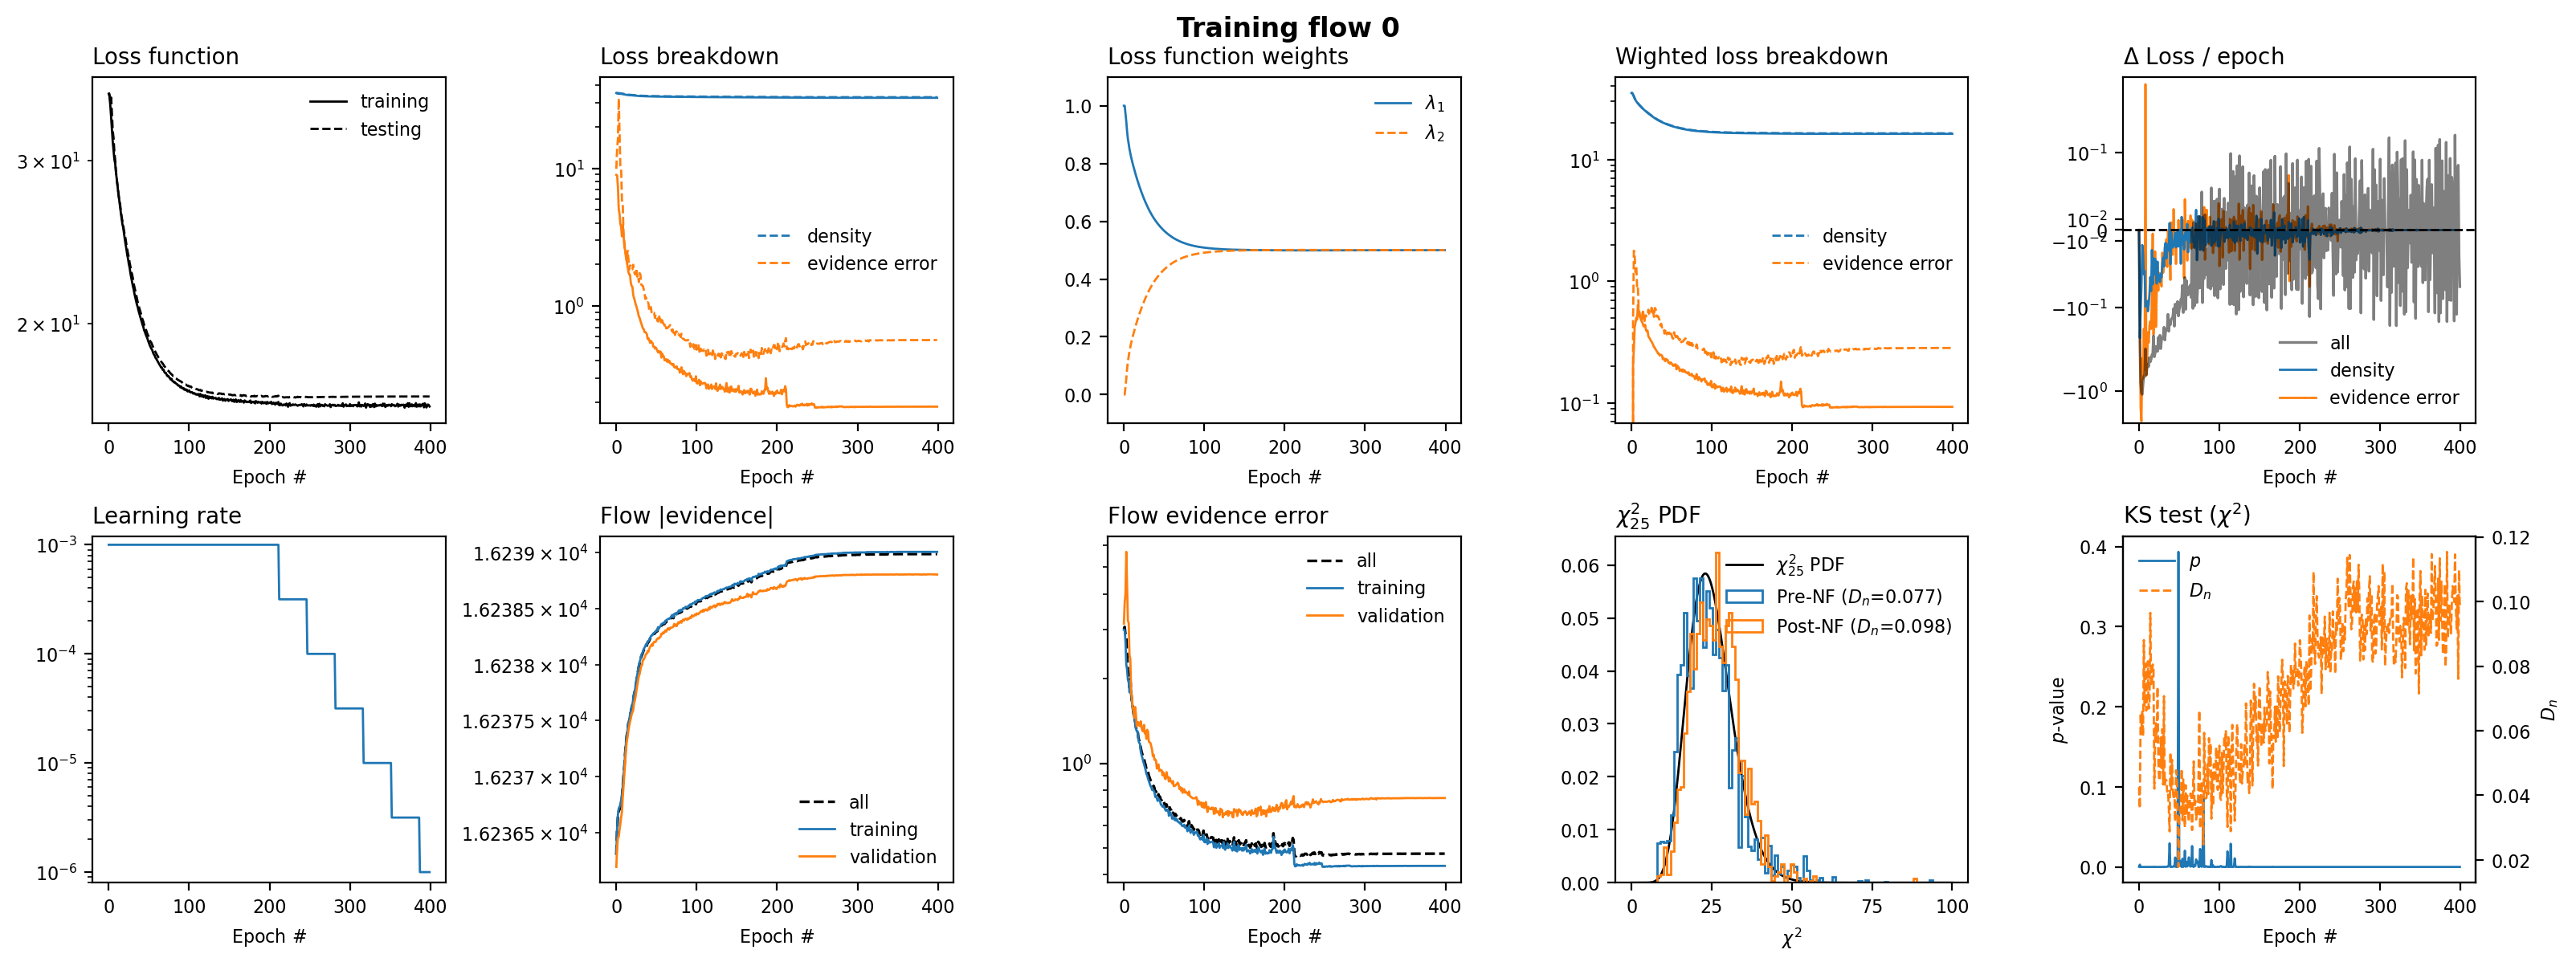

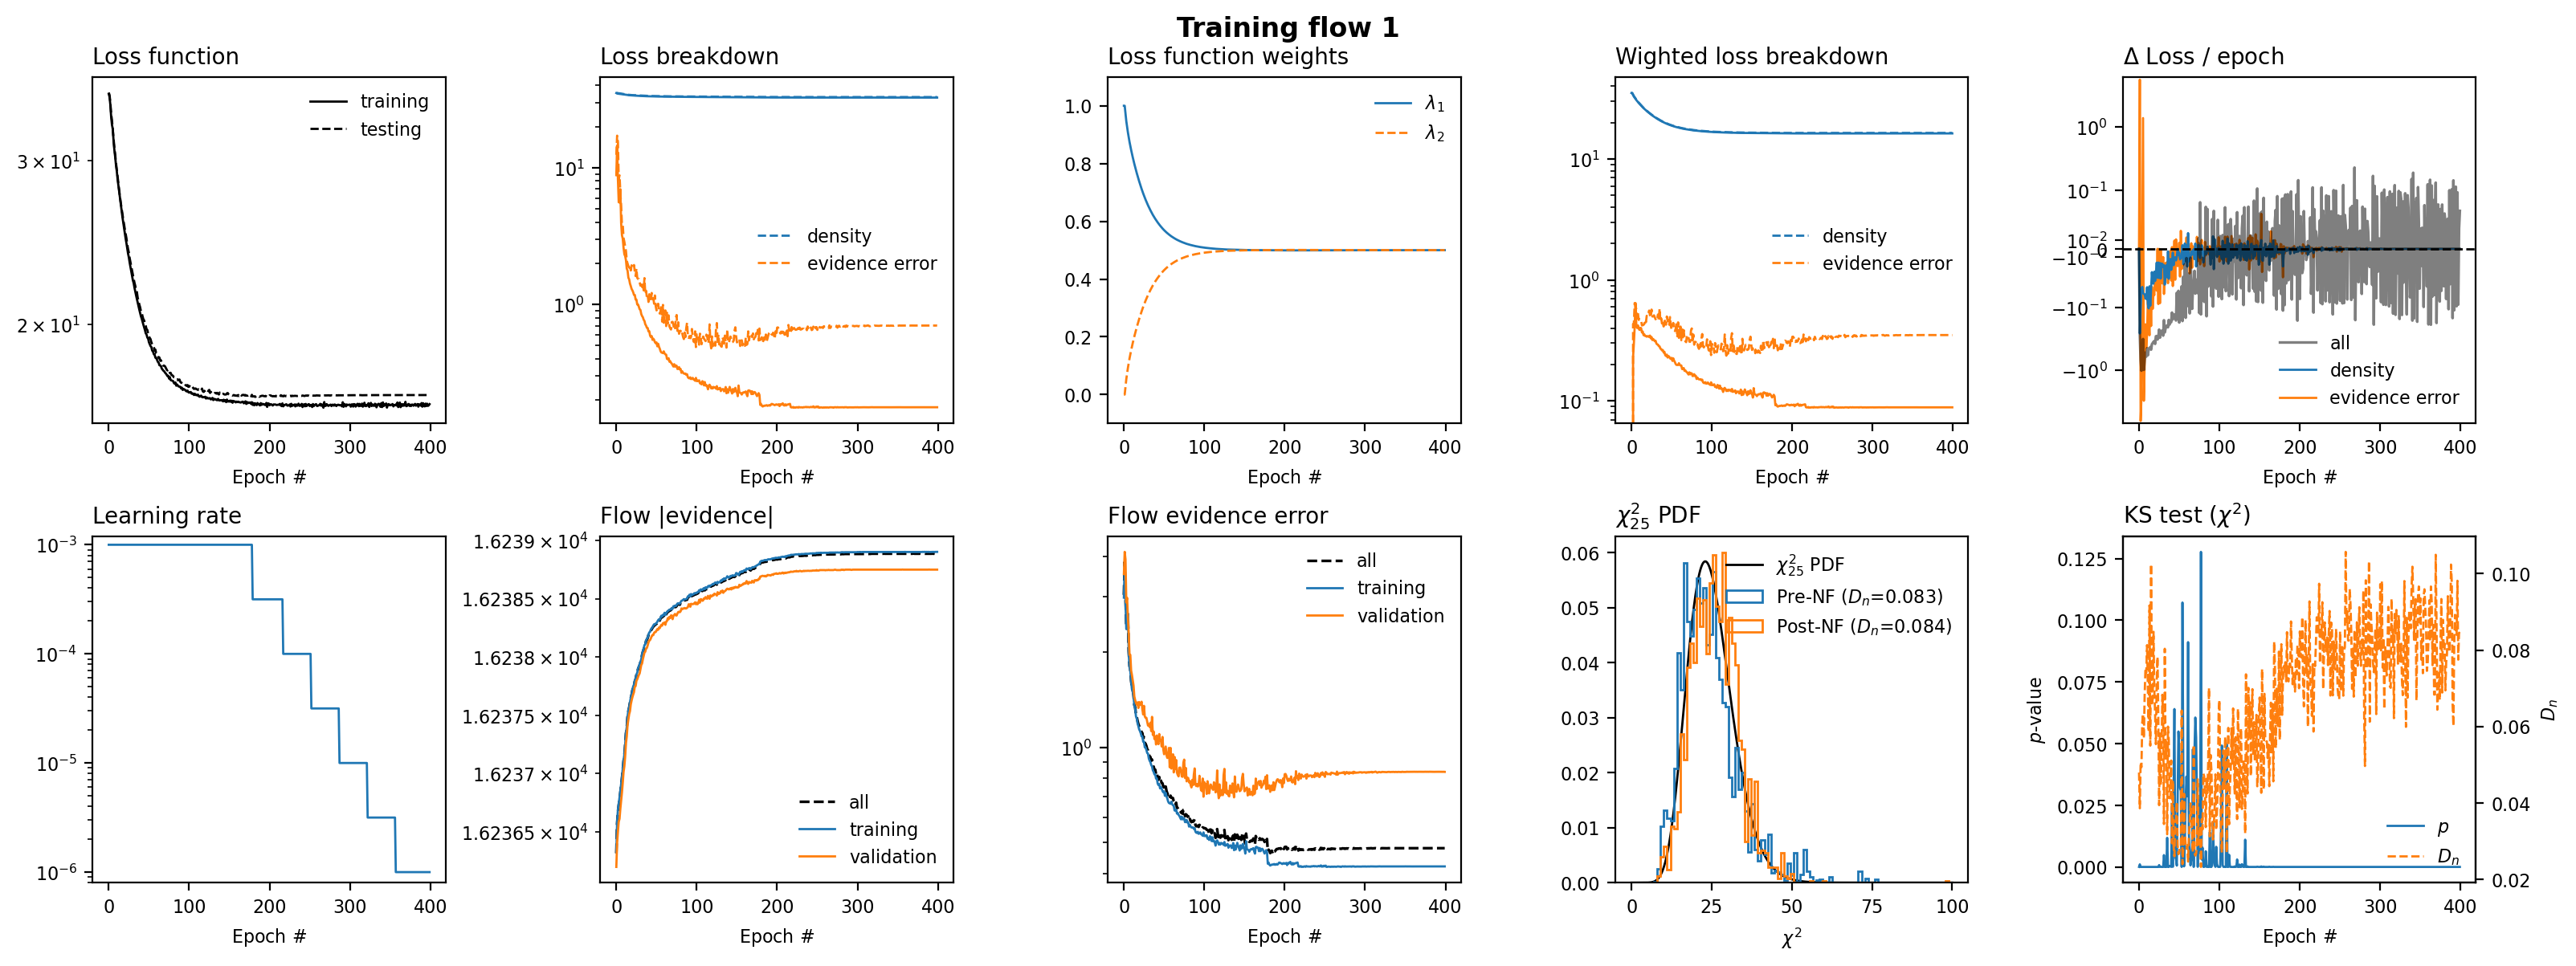

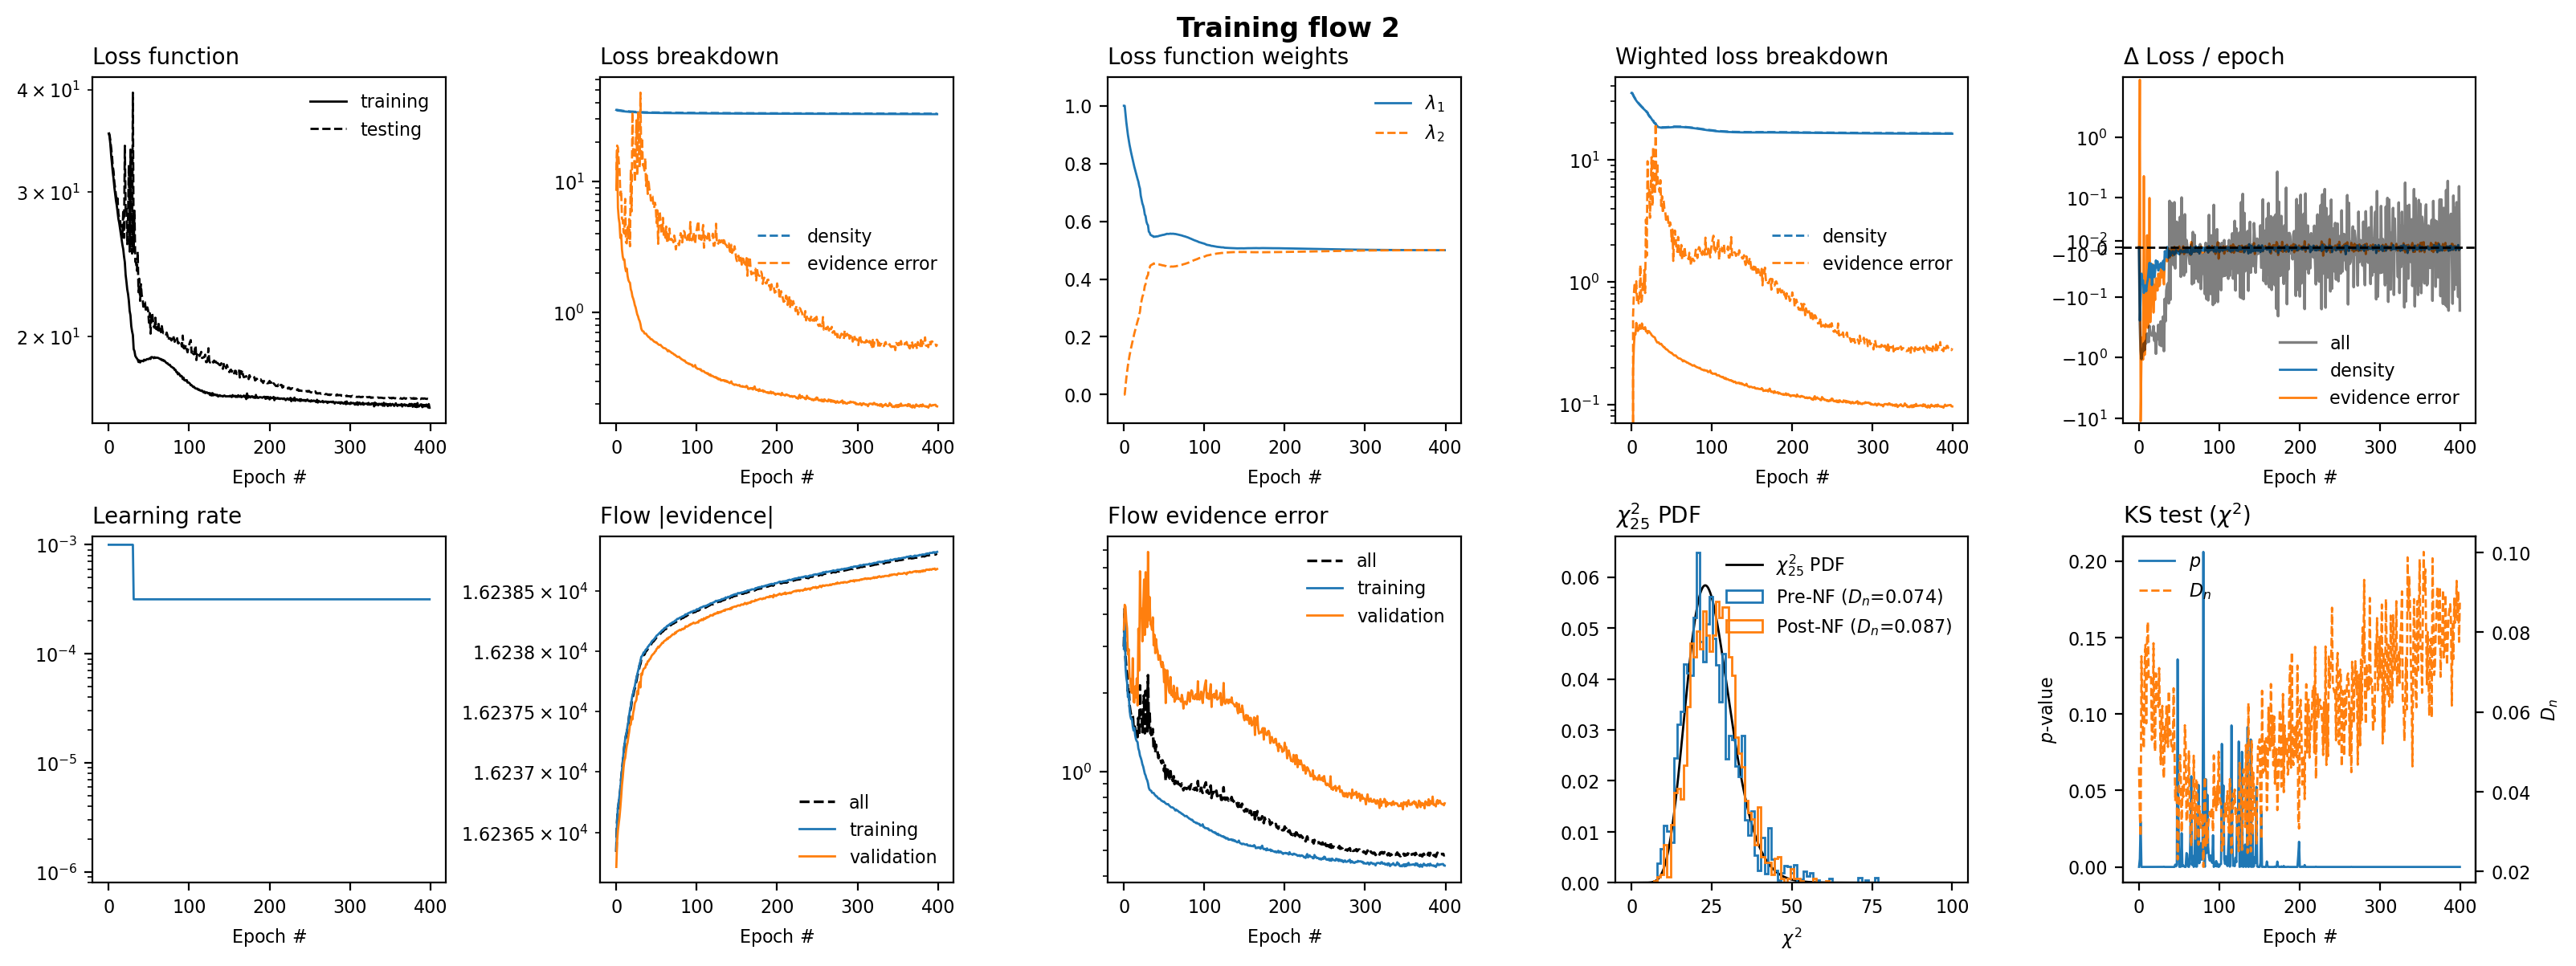

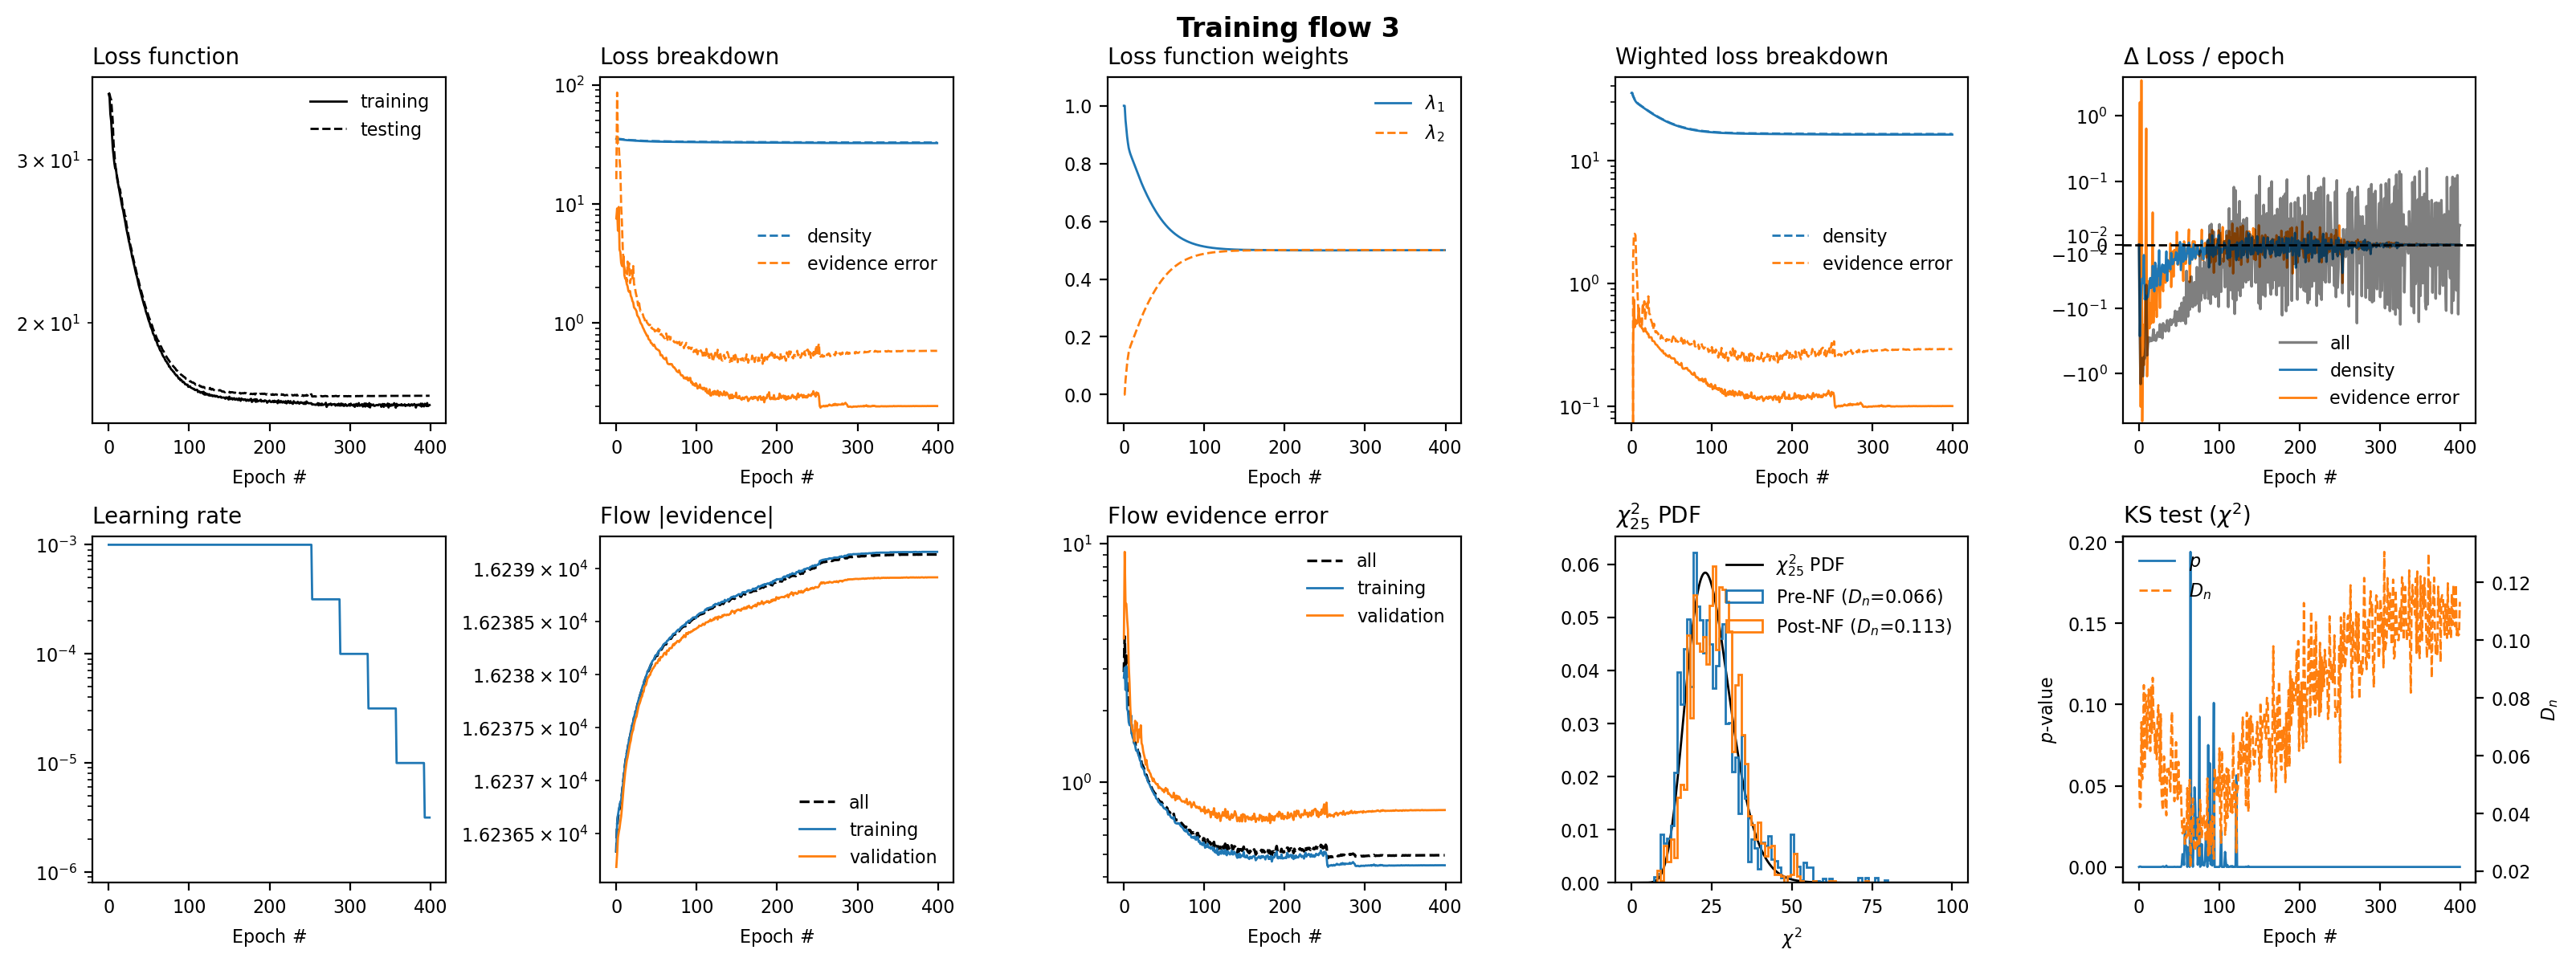

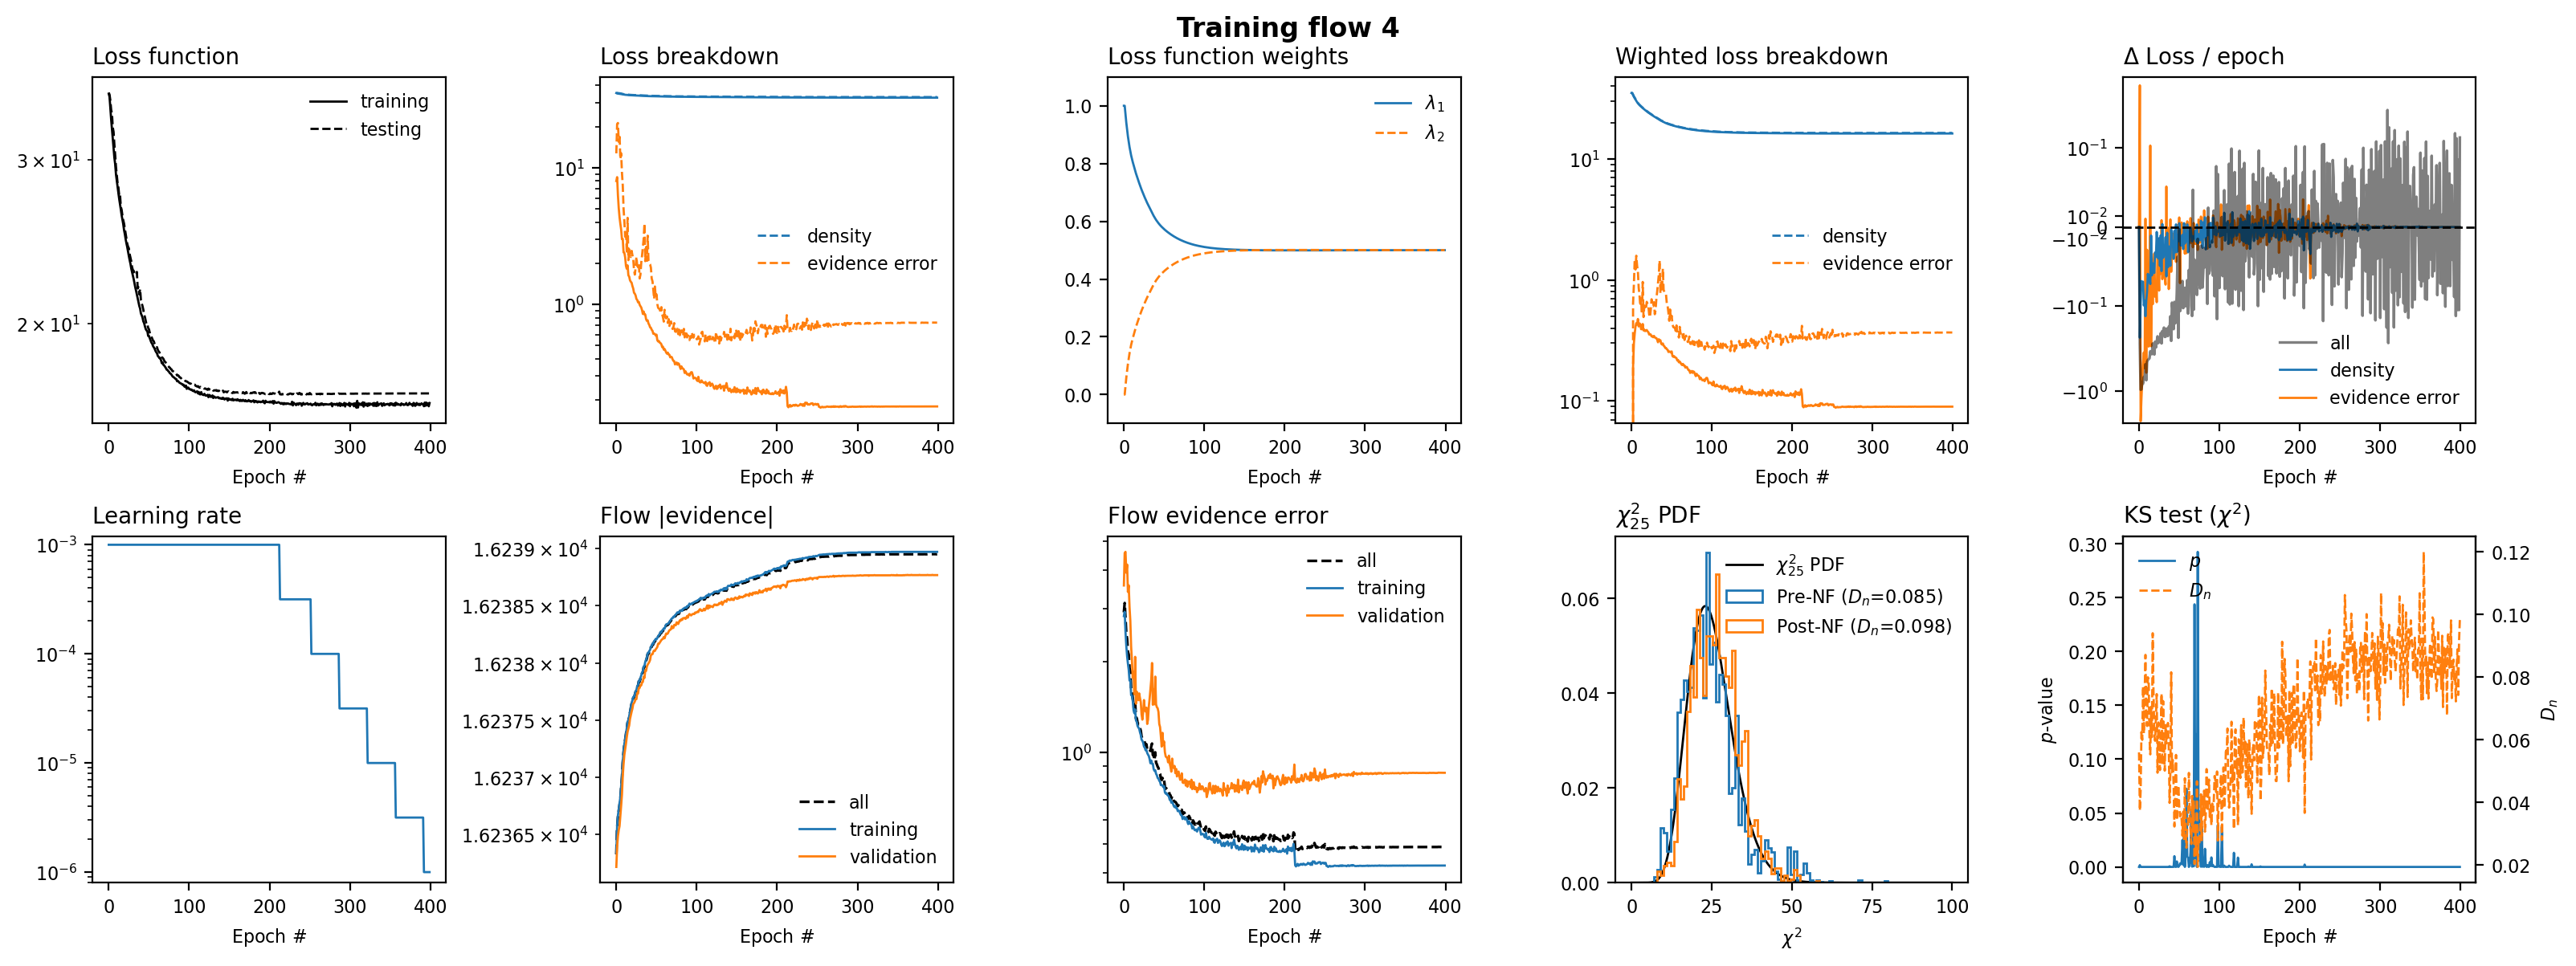

In [17]:
# most methods are implemented for the average flow as well:
average_flow_w0wa.training_plot()

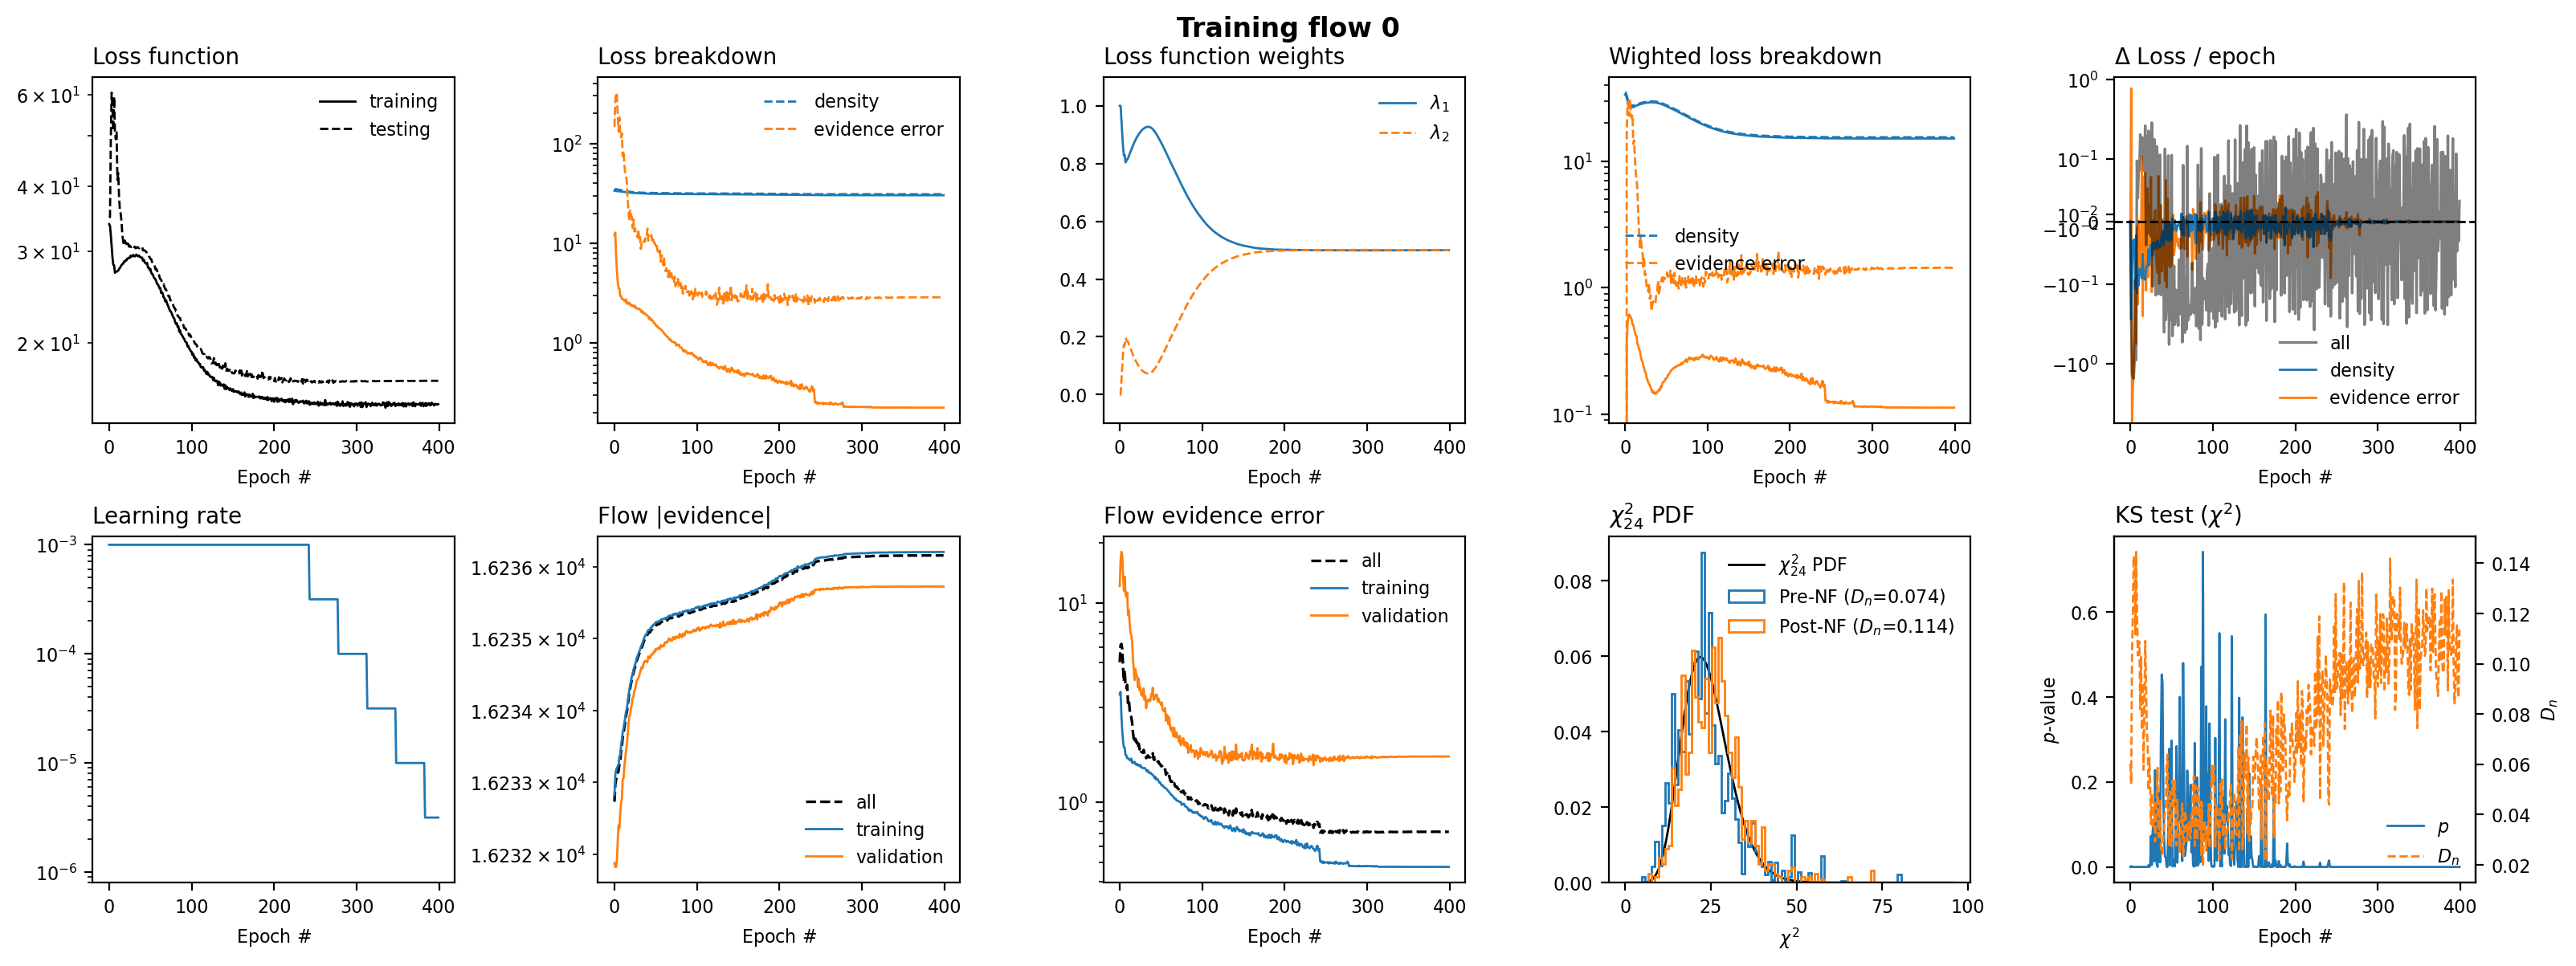

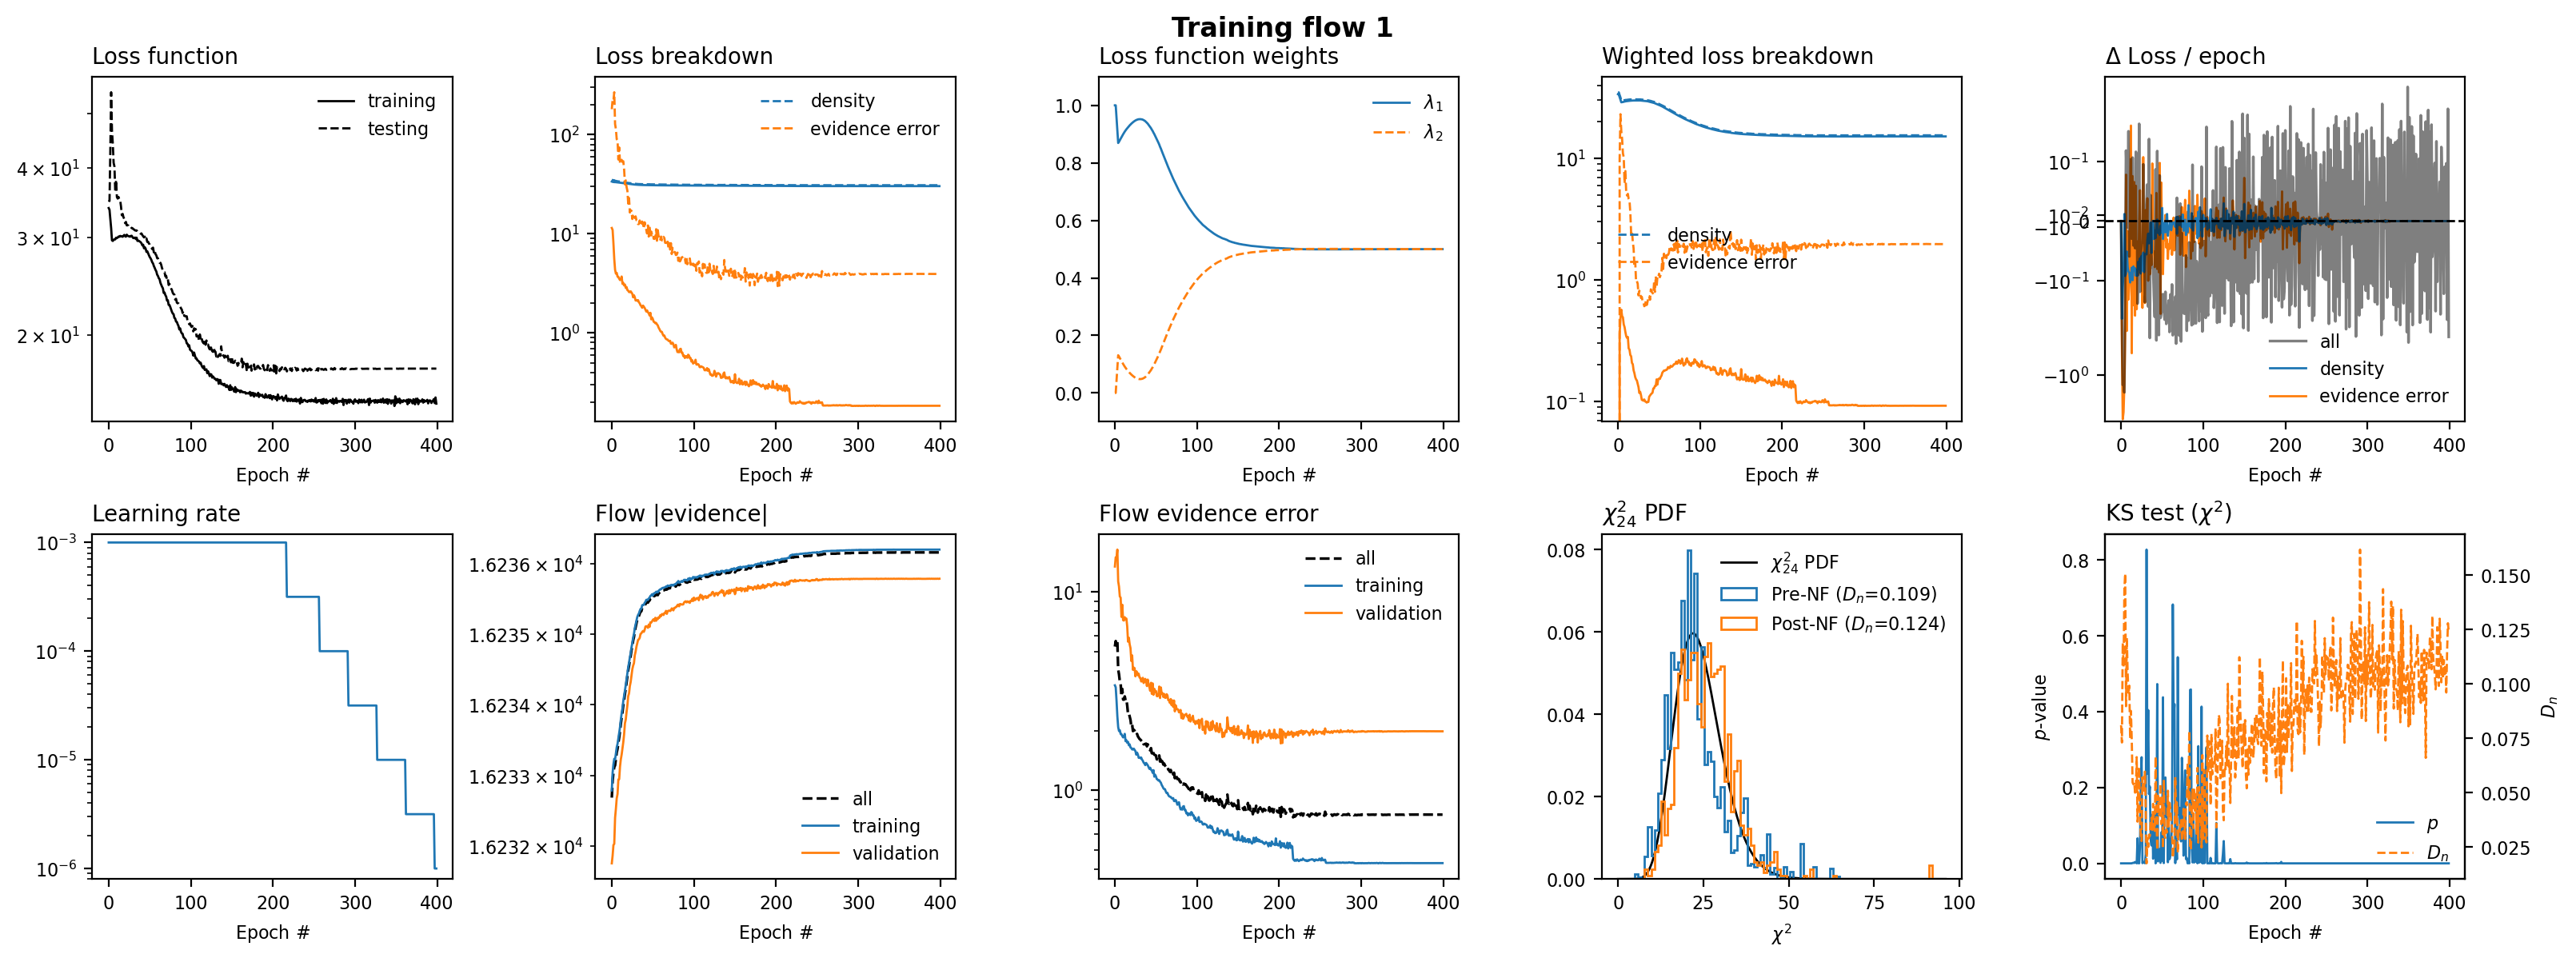

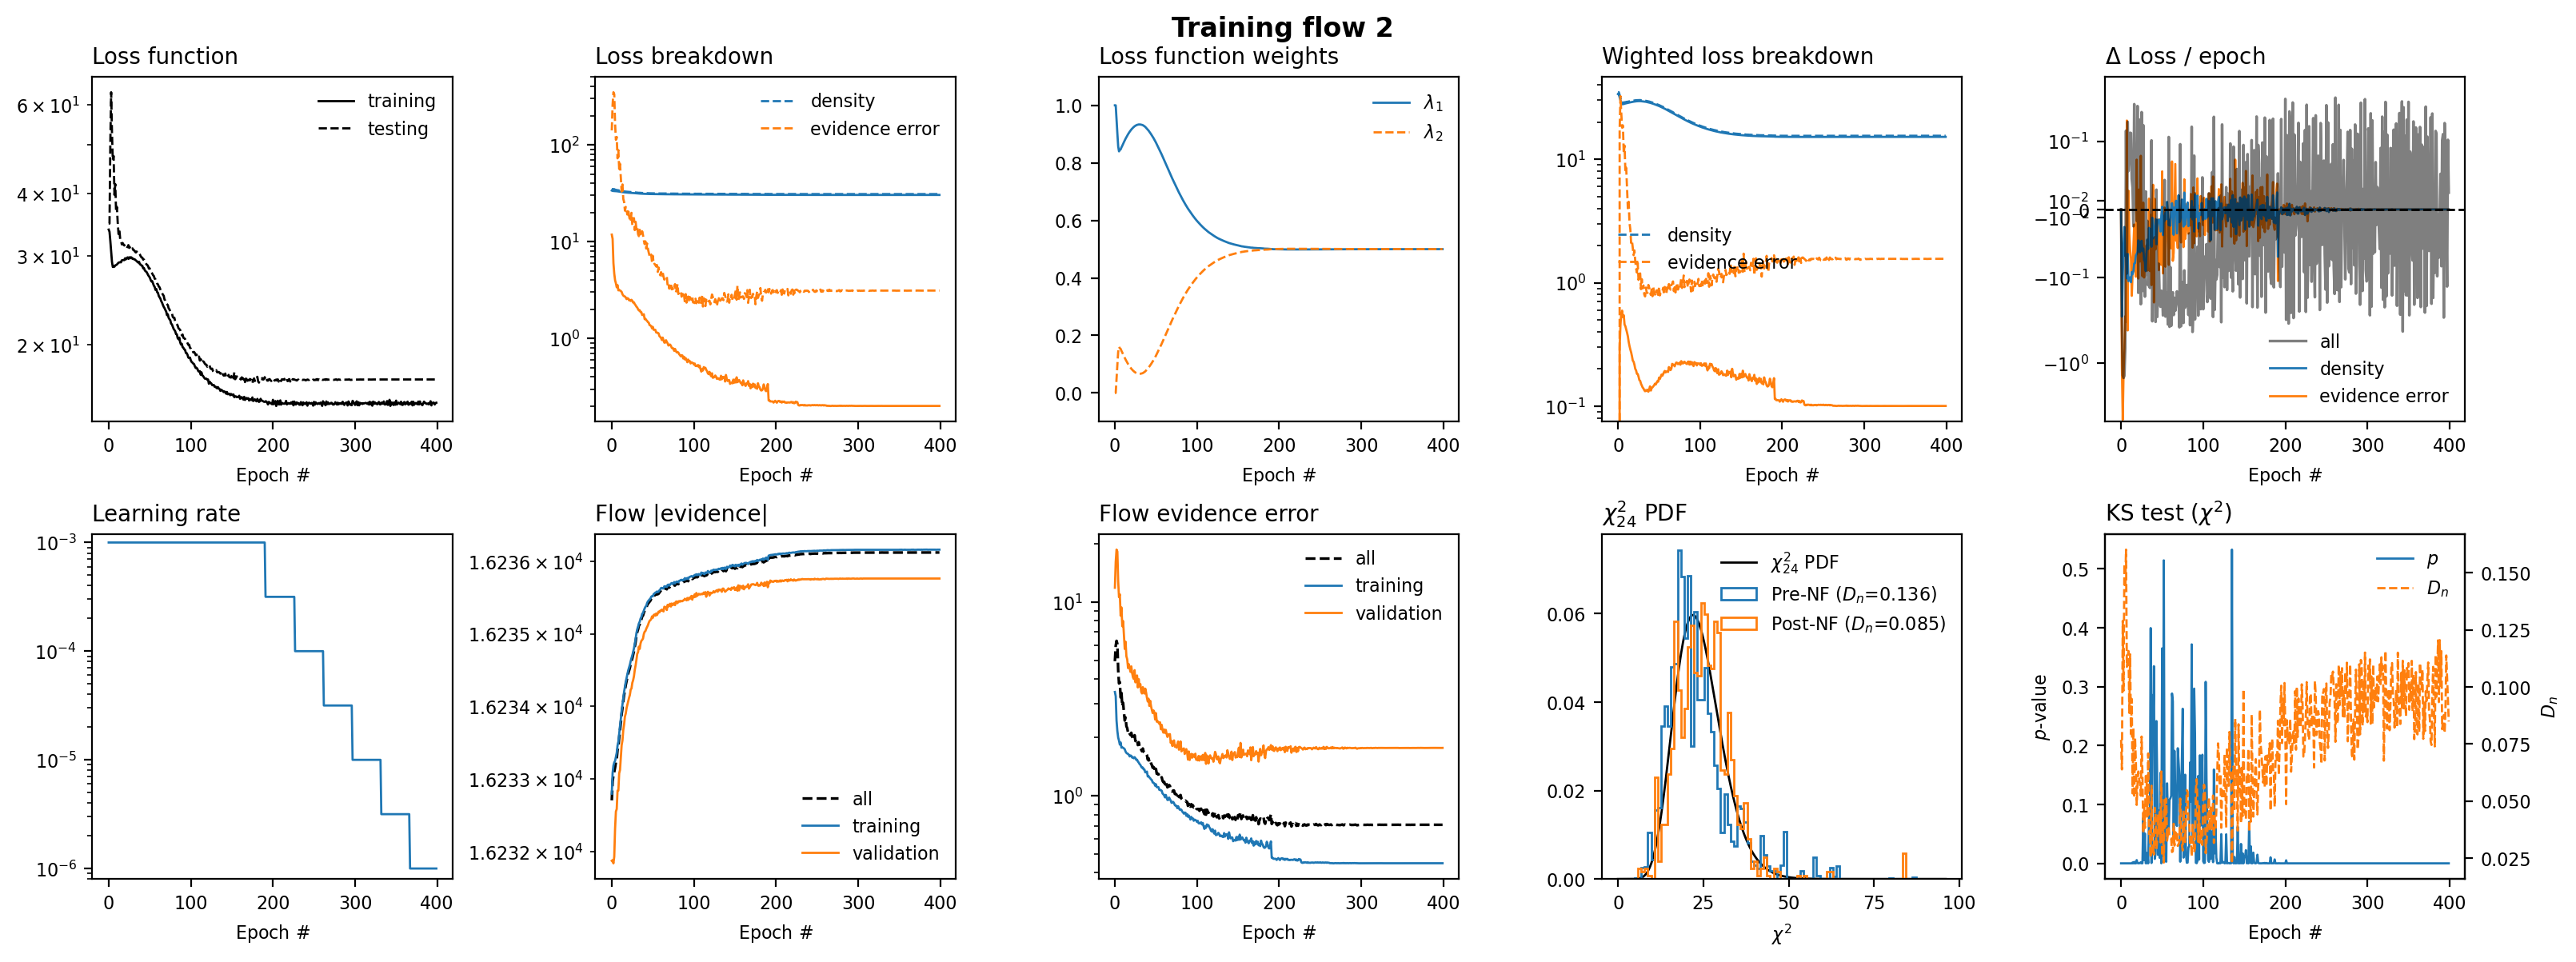

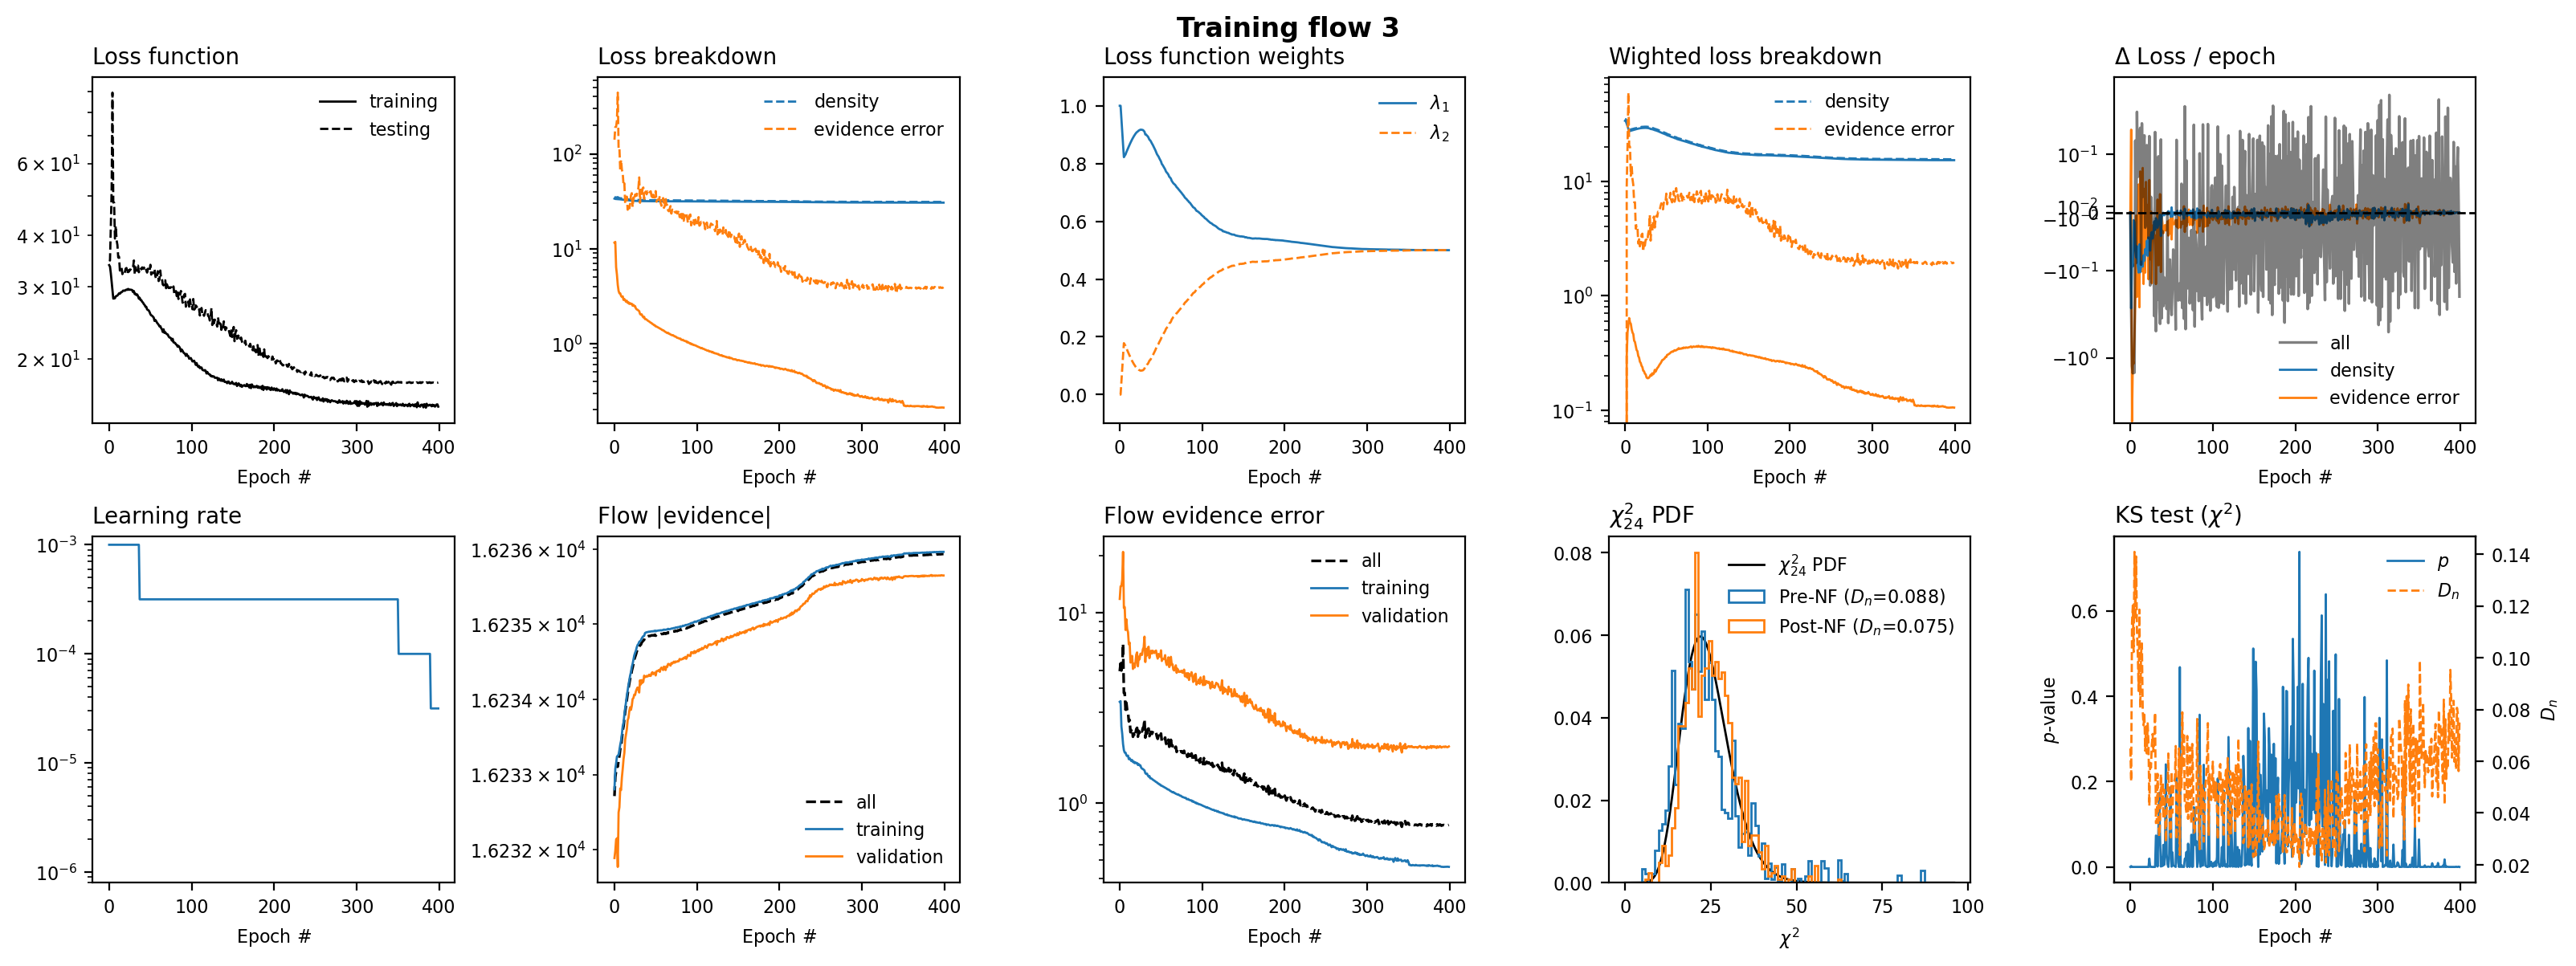

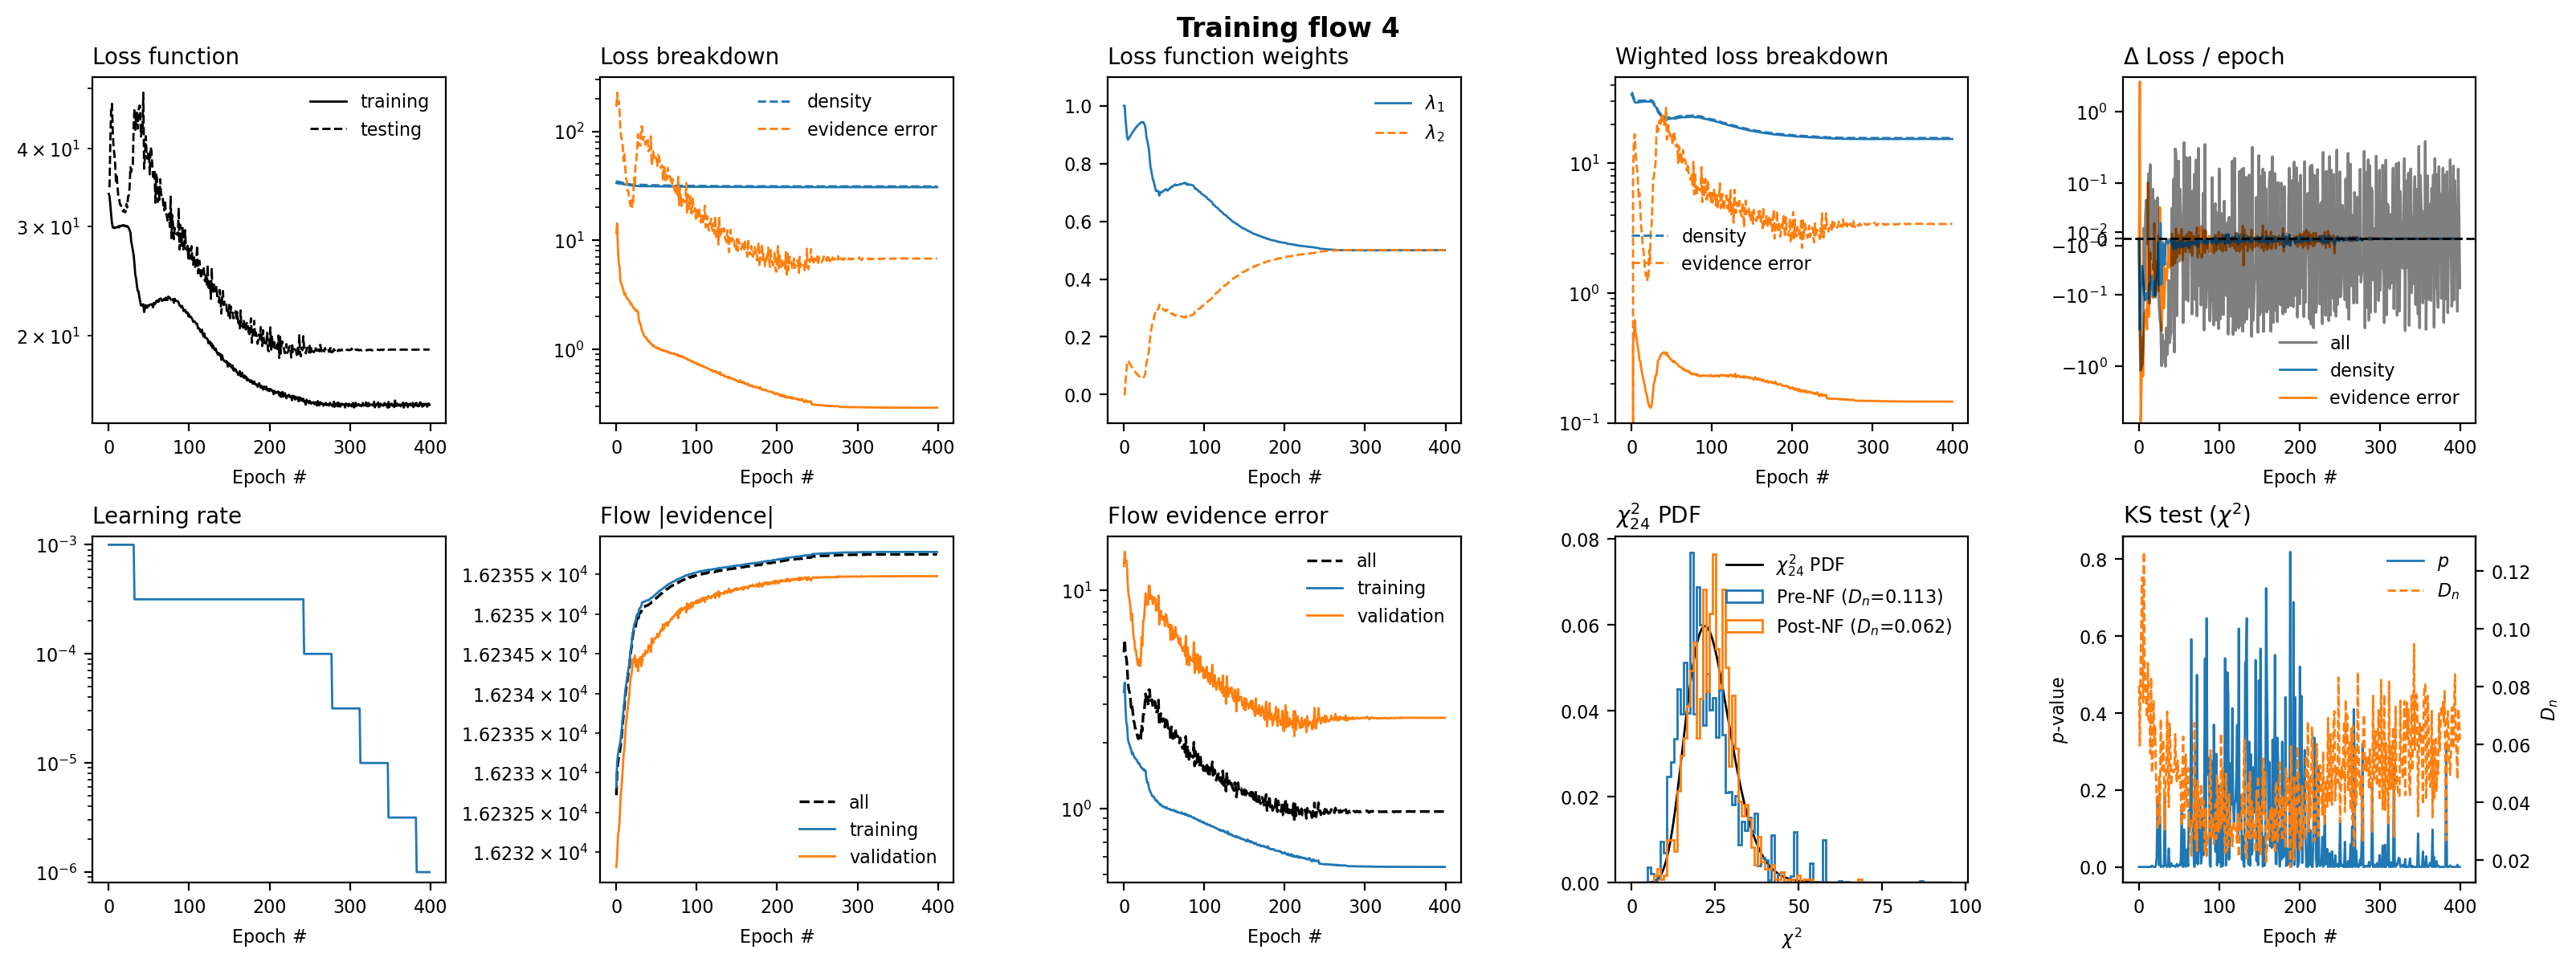

In [18]:
# most methods are implemented for the average flow as well:
average_flow_exp.training_plot()

In [19]:
# and we can print the training summary, which in this case contains more info:
average_flow_lcdm.print_training_summary()

Number of flows: 5
Flow weights   : [0.2  0.21 0.2  0.2  0.2 ]
loss                   : [14.89 14.79 14.87 14.94 14.81]
val_loss               : [15.   14.97 15.02 15.01 14.99]
lr                     : [1.00e-04 3.16e-04 3.16e-04 3.16e-05 3.16e-04]
rho_loss               : [29.53 29.44 29.48 29.61 29.47]
ee_loss                : [0.22 0.24 0.24 0.2  0.24]
val_rho_loss           : [29.62 29.51 29.57 29.68 29.55]
val_ee_loss            : [0.39 0.46 0.5  0.36 0.46]
loss_rate              : [-0.01 -0.04  0.02  0.05 -0.04]
rho_loss_rate          : [ 0.  0. -0.  0.  0.]
ee_loss_rate           : [-0. -0.  0. -0.  0.]
chi2Z_ks               : [0.07 0.06 0.06 0.06 0.07]
chi2Z_ks_p             : [1.23e-18 6.98e-16 6.03e-16 9.82e-16 1.53e-21]
training_evidence      : [-16241.53 -16241.63 -16241.59 -16241.46 -16241.59]
training_evidence_error: [0.47 0.49 0.49 0.45 0.49]
test_evidence          : [-16241.38 -16241.48 -16241.43 -16241.31 -16241.45]
test_evidence_error    : [0.63 0.68 0.71 0.6  0.68]


In [20]:
# and we can print the training summary, which in this case contains more info:
average_flow_w0wa.print_training_summary()

Number of flows: 5
Flow weights   : [0.21 0.19 0.2  0.22 0.19]
loss                   : [16.31 16.44 16.36 16.29 16.42]
val_loss               : [16.71 16.81 16.77 16.67 16.82]
lr                     : [1.00e-06 1.00e-06 3.16e-04 3.16e-06 1.00e-06]
rho_loss               : [32.53 32.63 32.71 32.37 32.56]
ee_loss                : [0.19 0.18 0.19 0.2  0.18]
val_rho_loss           : [32.86 32.92 32.99 32.75 32.9 ]
val_ee_loss            : [0.57 0.7  0.57 0.59 0.74]
loss_rate              : [-0.06  0.05 -0.17  0.02  0.13]
rho_loss_rate          : [ 2.67e-05  1.14e-05 -2.65e-03  6.10e-05 -2.29e-05]
ee_loss_rate           : [-3.33e-05 -1.91e-05 -6.03e-04 -7.59e-05  1.72e-05]
chi2Z_ks               : [0.1  0.08 0.09 0.11 0.1 ]
chi2Z_ks_p             : [1.85e-21 4.29e-16 3.11e-17 1.11e-28 9.49e-22]
training_evidence      : [-16239.   -16238.9  -16238.83 -16239.16 -16238.97]
training_evidence_error: [0.43 0.42 0.44 0.45 0.42]
test_evidence          : [-16238.8  -16238.75 -16238.68 -16238.92 -16

In [21]:
# and we can print the training summary, which in this case contains more info:
average_flow_exp.print_training_summary()

Number of flows: 5
Flow weights   : [0.31 0.19 0.28 0.18 0.04]
loss                   : [15.27 15.09 15.32 15.28 15.49]
val_loss               : [16.94 17.44 17.04 17.5  19.02]
lr                     : [3.16e-06 1.00e-06 1.00e-06 3.16e-05 1.00e-06]
rho_loss               : [30.3  30.31 30.35 30.54 30.72]
ee_loss                : [0.23 0.18 0.2  0.21 0.29]
val_rho_loss           : [31.02 30.96 30.98 31.1  31.26]
val_ee_loss            : [2.88 3.94 3.12 3.92 6.81]
loss_rate              : [ 0.03 -0.39  0.02 -0.2  -0.08]
rho_loss_rate          : [ 3.24e-05 -7.63e-06 -5.72e-06  0.00e+00 -3.43e-05]
ee_loss_rate           : [-8.63e-05 -4.12e-05 -8.20e-06 -3.14e-04  3.42e-05]
chi2Z_ks               : [0.11 0.12 0.08 0.07 0.06]
chi2Z_ks_p             : [1.44e-14 2.92e-17 2.57e-08 1.37e-06 1.37e-04]
training_evidence      : [-16236.2  -16236.2  -16236.16 -16235.96 -16235.78]
training_evidence_error: [0.47 0.43 0.45 0.46 0.54]
test_evidence          : [-16235.72 -16235.79 -16235.76 -16235.65 -16

In [ ]:
avg_samples_lcdm = average_flow_lcdm.MCSamples(20000)
avg_samples_lcdm.name_tag = 'Average Flow LCDM'
temp_samples_lcdm = [_f.MCSamples(20000) for _f in average_flow_lcdm.flows]
for i, _s in enumerate(temp_samples_lcdm):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([samples_lcdm, avg_samples_lcdm] + temp_samples_lcdm,
                filled=False)

"\navg_samples_lcdm = average_flow_lcdm.MCSamples(20000)\navg_samples_lcdm.name_tag = 'Average Flow LCDM'\ntemp_samples_lcdm = [_f.MCSamples(20000) for _f in average_flow_lcdm.flows]\nfor i, _s in enumerate(temp_samples_lcdm):\n    _s.name_tag = _s.name_tag + f'_{i}'\n# let's plot the flows:\ng = plots.get_subplot_plotter()\ng.triangle_plot([chain_lcdm, avg_samples_lcdm] + temp_samples_lcdm,\n                filled=False)\n\navg_samples_w0wa = average_flow_w0wa.MCSamples(20000)\navg_samples_w0wa.name_tag = 'Average Flow W0WA'\ntemp_samples_w0wa = [_f.MCSamples(20000) for _f in average_flow_w0wa.flows]\nfor i, _s in enumerate(temp_samples_w0wa):\n    _s.name_tag = _s.name_tag + f'_{i}'\n# let's plot the flows:\ng = plots.get_subplot_plotter()\ng.triangle_plot([chain_w0wa, avg_samples_w0wa] + temp_samples_w0wa,\n                filled=False)\n\navg_samples_exp = average_flow_exp.MCSamples(20000)\navg_samples_exp.name_tag = 'Average Flow EXP'\ntemp_samples_exp = [_f.MCSamples(20000) for _

In [ ]:
avg_samples_w0wa = average_flow_w0wa.MCSamples(20000)
avg_samples_w0wa.name_tag = 'Average Flow W0WA'
temp_samples_w0wa = [_f.MCSamples(20000) for _f in average_flow_w0wa.flows]
for i, _s in enumerate(temp_samples_w0wa):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([samples_w0wa, avg_samples_w0wa] + temp_samples_w0wa,
                filled=False)

In [ ]:
avg_samples_exp = average_flow_exp.MCSamples(20000)
avg_samples_exp.name_tag = 'Average Flow EXP'
temp_samples_exp = [_f.MCSamples(20000) for _f in average_flow_exp.flows]
for i, _s in enumerate(temp_samples_exp):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([samples_exp, avg_samples_exp] + temp_samples_exp,
                filled=False)


In [29]:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')

LCDM: log(Z) = -16241.553698522705 +- 0.357574375413495
W0WA: log(Z) = -16238.968805062035 +- 0.3421887971290322
EXP: log(Z) = -16236.124340659328 +- 0.47740845866617376


### Advanced Topic: Evidence 

In [ ]:
validation_flow_log10_P = average_flow_lcdm.log_probability(average_flow_lcdm.cast(samples_lcdm.samples[average_flow_lcdm.test_idx, :])).numpy()/np.log(10.)
validation_samples_log10_P = -samples_lcdm.loglikes[average_flow_lcdm.test_idx]/np.log(10.)  # notice the minus sign due to the definition of logP in getdist
training_flow_log10_P = average_flow_lcdm.log_probability(average_flow_lcdm.cast(samples_lcdm.samples[average_flow_lcdm.training_idx, :])).numpy()/np.log(10.)
training_samples_log10_P = -samples_lcdm.loglikes[average_flow_lcdm.training_idx]/np.log(10.)  # notice the minus sign due to the definition of logP in getdist

# do the plot:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, range=[-1., 1.], density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, range=[-1., 1.], density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()

In [ ]:
validation_flow_log10_P = average_flow_w0wa.log_probability(average_flow_w0wa.cast(samples_w0wa.samples[average_flow_w0wa.test_idx, :])).numpy()/np.log(10.)
validation_samples_log10_P = -samples_w0wa.loglikes[average_flow_w0wa.test_idx]/np.log(10.)  # notice the minus sign due to the definition of logP in getdist
training_flow_log10_P = average_flow_w0wa.log_probability(average_flow_w0wa.cast(samples_w0wa.samples[average_flow_w0wa.training_idx, :])).numpy()/np.log(10.)
training_samples_log10_P = -samples_w0wa.loglikes[average_flow_w0wa.training_idx]/np.log(10.)  # notice the minus sign due to the definition of logP in getdist

# do the plot:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, range=[-1., 1.], density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, range=[-1., 1.], density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()

In [ ]:
validation_flow_log10_P = average_flow_exp.log_probability(average_flow_exp.cast(samples_exp.samples[average_flow_exp.test_idx, :])).numpy()/np.log(10.)
validation_samples_log10_P = -samples_exp.loglikes[average_flow_exp.test_idx]/np.log(10.)  # notice the minus sign due to the definition of logP in getdist
training_flow_log10_P = average_flow_exp.log_probability(average_flow_exp.cast(samples_exp.samples[average_flow_exp.training_idx, :])).numpy()/np.log(10.)
training_samples_log10_P = -samples_exp.loglikes[average_flow_exp.training_idx]/np.log(10.)  # notice the minus sign due to the definition of logP in getdist

# do the plot:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(training_samples_log10_P - np.amax(training_samples_log10_P), training_flow_log10_P - training_samples_log10_P, s=0.1, label='training')
ax1.scatter(validation_samples_log10_P - np.amax(validation_samples_log10_P), validation_flow_log10_P - validation_samples_log10_P, s=0.5, label='validation')
ax1.legend()
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('$\log_{10}(P_{\\rm true}/P_{\\rm max})$')
ax1.set_ylabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
ax1.set_ylim(-1.0, 1.0)

ax2.hist(training_flow_log10_P - training_samples_log10_P, bins=50, range=[-1., 1.], density=True, alpha=0.5, label='training')
ax2.hist(validation_flow_log10_P - validation_samples_log10_P, bins=50, range=[-1., 1.], density=True, alpha=0.5, label='validation')
ax2.legend()
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('$\log_{10}(P_{\\rm flow}) - \log_{10}(P_{\\rm true})$')
ax2.set_xlim([-1.0, 1.0])

plt.tight_layout()
plt.show()